# Análisis Avanzado de Rendimientos de Molienda — Impacto Ventanas Teniente 8
## Notebook Maestro · División El Teniente · Codelco

---


## 0. Resumen Ejecutivo

### Objetivo
Cuantificar el impacto de las ventanas de mantenimiento del tren **Teniente 8 (T8)** sobre los circuitos de molienda SAG 1, SAG 2, PMC (Molinos 1-12) y Unitario (Molino 13), mediante analítica operacional avanzada.

### Preguntas de negocio
1. ¿Qué molino es más sensible a las ventanas T8?
2. ¿Cuántos TPH se pierden por hora de ventana?
3. ¿Existe efecto acumulado por ventanas consecutivas?
4. ¿Qué duración de ventana genera mayor daño: 2h, 4h o 12h?
5. ¿Cuánto tarda la recuperación del rendimiento?
6. ¿Existe evidencia de consumo de pilas de alimentación?
7. ¿Qué modelo predice mejor el rendimiento?
8. ¿Qué acciones operacionales se recomiendan?

### Fuentes de datos
| Fuente | Ruta | Descripción |
|--------|------|-------------|
| PAM Producción | `data/raw/PAM_Produccion/` | Programa diario por activo |
| PAM Mantto | `data/raw/PAM_Mantto/` | Horas T8 por día |
| Rendimientos | `data/raw/Rendimientos/` | TPH real 5-min |

### Supuestos
- TPH ≤ 0 → detenido. Umbral operacional ≥ 50 TPH para análisis estadístico.
- horas_t8 = 0 sin ventana; 2, 4, 12 ventana corta/media/larga.
- Pila de alimentación: capacidad operacional SAG ~36h, Conv ~18h.
- Datos de 5 min; frecuencia de agrupación diaria para análisis T8.


---
## 1. Configuración

In [1]:
import sys, json, re, math, warnings, logging, os
from pathlib import Path
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s|%(message)s')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import openpyxl
import yaml
from scipy import stats
from scipy.stats import (ttest_ind, mannwhitneyu, ks_2samp, kruskal,
                          f_oneway, spearmanr, pearsonr, skew, kurtosis)
from scipy.signal import correlate
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from dotenv import load_dotenv
from tqdm.auto import tqdm

matplotlib.rcParams.update({'figure.dpi':120,'font.size':9,'axes.titlesize':10})
sns.set_style('whitegrid')
RNG = np.random.default_rng(42)

# ── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\jorel038\OneDrive - Codelco\Documentos\AA_CIO_DET\07_Rendimientos')
sys.path.insert(0, str(BASE_DIR))
RAW_PROD   = BASE_DIR/'data'/'raw'/'PAM_Produccion'
RAW_MANTTO = BASE_DIR/'data'/'raw'/'PAM_Mantto'
RAW_REND   = BASE_DIR/'data'/'raw'/'Rendimientos'
INTERM     = BASE_DIR/'data'/'intermediate'
PROCESSED  = BASE_DIR/'data'/'processed'
OUT_FIG    = BASE_DIR/'outputs'/'figures'
OUT_XLS    = BASE_DIR/'outputs'/'excel'
OUT_RPT    = BASE_DIR/'outputs'/'reports'
OUT_MDL    = BASE_DIR/'outputs'/'models'
LOGS_DIR   = BASE_DIR/'logs'
for d in [INTERM,PROCESSED,OUT_FIG,OUT_XLS,OUT_RPT,OUT_MDL,LOGS_DIR]:
    d.mkdir(parents=True,exist_ok=True)

# ── Parámetros operacionales ────────────────────────────────────────────────
ACTIVOS           = ['SAG1','SAG2','PMC','UNITARIO']
FREQ_MIN          = 5
DT_H              = FREQ_MIN / 60.0
TPH_STOP_THRESHOLD= 0     # param usuario
TPH_OPERATIONAL   = 50    # skill_molienda_sag: ≤50 = coef estado, no TPH real
PRE_WINDOWS_HOURS = [24, 48, 72]
POST_WINDOWS_HOURS= [24, 48, 72]
RECOVERY_LEVELS   = [0.80, 0.90, 0.95, 1.00]
PHYSICAL_MAX      = {'SAG1':2500,'SAG2':2500,'PMC':1800,'UNITARIO':1000}
AUTONOMIA_H       = {'SAG':36,'Conv':18}  # skill_operaciones_mina_subterranea

# ── Buckets T8 ────────────────────────────────────────────────────────────
BINS_T8   = [-0.001, 0, 2, 4, 12, 25]
LABELS_T8 = ['Sin ventana','Corta 2h','Media 4h','Larga 12h','Muy larga']

# ── Colores ───────────────────────────────────────────────────────────────
try:
    with open(BASE_DIR/'config'/'config.yaml','r',encoding='utf-8') as f:
        CFG=yaml.safe_load(f)
    COLORES=CFG.get('visualizacion',{}).get('colores',{})
except:
    COLORES={}
COLORES.setdefault('SAG1','steelblue'); COLORES.setdefault('SAG2','darkorange')
COLORES.setdefault('PMC','seagreen'); COLORES.setdefault('UNITARIO','purple')
COLORES.setdefault('MUN','purple')

# ── Claude API ─────────────────────────────────────────────────────────────
load_dotenv(BASE_DIR/'.env')
ANTHROPIC_KEY   = os.environ.get('ANTHROPIC_API_KEY','')
ANTHROPIC_MODEL = os.environ.get('ANTHROPIC_MODEL','claude-sonnet-4-6')
ANTHROPIC_MAXTOK= int(os.environ.get('ANTHROPIC_MAX_TOKENS',1000))
TIENE_CLAUDE = bool(ANTHROPIC_KEY and 'REEMPLAZAR' not in ANTHROPIC_KEY)

# ── Librerías opcionales ─────────────────────────────────────────────────
TIENE_XGB=TIENE_LGB=TIENE_CAT=TIENE_SHAP=TIENE_RUPTURES=False
try: import xgboost as xgb; TIENE_XGB=True
except: pass
try: import lightgbm as lgb; TIENE_LGB=True
except: pass
try: import catboost as cb; TIENE_CAT=True
except: pass
try: import shap; TIENE_SHAP=True
except: pass
try: import ruptures as rpt; TIENE_RUPTURES=True
except: pass

print('XGB:',TIENE_XGB,'LGB:',TIENE_LGB,'CAT:',TIENE_CAT,
      'SHAP:',TIENE_SHAP,'ruptures:',TIENE_RUPTURES,'Claude:',TIENE_CLAUDE)
print('BASE_DIR:',BASE_DIR)

XGB: True LGB: True CAT: True SHAP: True ruptures: True Claude: True
BASE_DIR: C:\Users\jorel038\OneDrive - Codelco\Documentos\AA_CIO_DET\07_Rendimientos


---
## 2. Revisión de Skills (Obligatorio)

In [2]:
SKILLS_DIR = BASE_DIR / 'Skills'
skills_all = sorted([f.stem for f in SKILLS_DIR.glob('*.md')]) if SKILLS_DIR.exists() else []
SKILLS_UTILIZADOS = [
    'skill_molienda_sag','skill_operaciones_mina_subterranea',
    'skill_estadistica_bayesiana_avanzada','skill_machine_learning_operacional',
    'skill_series_temporales_industriales','skill_data_scientist_senior',
    'skill_data_quality_governance','skill_explainable_ai_governance',
    'skill_ai_llm_engineer','skill_optimizacion_tokens_ia','skill_process_mining_industrial',
]
print(f'Skills detectados ({len(skills_all)}):')
for s in skills_all: print(f'  ✓ {s}')
print(f'\nSkills utilizados ({len(SKILLS_UTILIZADOS)}):')
for s in SKILLS_UTILIZADOS: print(f'  → {s}')
audit_entry={
    'fecha': datetime.now().isoformat(),
    'notebook': '00_master_analisis_rendimientos_t8.ipynb',
    'skills_revisados': skills_all,
    'skills_utilizados': SKILLS_UTILIZADOS,
    'archivos_afectados': ['data/processed/','outputs/'],
}
with open(LOGS_DIR/'skill_audit.log','a',encoding='utf-8') as f:
    f.write(json.dumps(audit_entry,ensure_ascii=False)+'\n')
print('\n✓ Audit log registrado.')

Skills detectados (17):
  ✓ skill_ai_llm_engineer
  ✓ skill_confiabilidad_mantenimiento_predictivo
  ✓ skill_data_product_architect
  ✓ skill_data_quality_governance
  ✓ skill_data_scientist_senior
  ✓ skill_estadistica_bayesiana_avanzada
  ✓ skill_explainable_ai_governance
  ✓ skill_forecasting_industrial
  ✓ skill_machine_learning_operacional
  ✓ skill_molienda_sag
  ✓ skill_operaciones_mina_subterranea
  ✓ skill_optimizacion_tokens_ia
  ✓ skill_process_mining_industrial
  ✓ skill_product_owner_analitica_minera
  ✓ skill_recommendation_systems_engineer
  ✓ skill_series_temporales_industriales
  ✓ skill_ux_ui_cio_operations_center

Skills utilizados (11):
  → skill_molienda_sag
  → skill_operaciones_mina_subterranea
  → skill_estadistica_bayesiana_avanzada
  → skill_machine_learning_operacional
  → skill_series_temporales_industriales
  → skill_data_scientist_senior
  → skill_data_quality_governance
  → skill_explainable_ai_governance
  → skill_ai_llm_engineer
  → skill_optimizacion_t

---
## 3. Ingesta de Datos

In [3]:
# ── 3.1 Rendimientos 5-min ──────────────────────────────────────────────
MESES_ES={k:v for k,v in zip(
    ['enero','febrero','marzo','abril','mayo','junio','julio','agosto',
     'septiembre','octubre','noviembre','diciembre'],range(1,13))}
def _norm(c): return re.sub(r'\s+',' ',str(c).strip().upper())
def _mes_anio(n):
    m=re.search(r'(20\d{2})',n.lower())
    anio=int(m.group(1)) if m else None
    mes=next((v for k,v in MESES_ES.items() if k in n.lower()),None)
    return mes,anio

INTERM_REND=INTERM/'rendimientos_clean.parquet'
if INTERM_REND.exists():
    df_rend_raw=pd.read_parquet(INTERM_REND)
    print(f'✓ Rendimientos desde parquet: {len(df_rend_raw):,} reg | {df_rend_raw["fecha"].min().date()} → {df_rend_raw["fecha"].max().date()}')
else:
    # Buscar en raw/Rendimientos primero, luego en raíz
    cand=[RAW_REND/'rendimientos_coef - copia.xlsx',
          BASE_DIR/'rendimientos_coef - copia.xlsx']
    rend_file=next((p for p in cand if p.exists()),None)
    assert rend_file,'No se encontró archivo de rendimientos'
    print('Leyendo:', rend_file)
    wb=openpyxl.load_workbook(rend_file,read_only=True,data_only=True)
    rows=list(wb.active.iter_rows(values_only=True)); wb.close()
    hdr=[_norm(c) for c in rows[0]]; cm={}
    for i,h in enumerate(hdr):
        if 'FECHA' in h: cm['fecha']=i
        elif 'SAG 1' in h or ('SAG1' in h and 'SAG2' not in h): cm['SAG1']=i
        elif 'SAG 2' in h or 'SAG2' in h: cm['SAG2']=i
        elif 'MUN' in h or 'UNITARIO' in h or 'MOLINO 13' in h: cm['UNITARIO']=i
        elif 'CONVENCIONAL' in h or 'PMC' in h or 'MOL 1' in h: cm['PMC']=i
    print('Columnas mapeadas:',cm)
    data=[]
    for row in rows[1:]:
        fecha=row[cm.get('fecha',0)]
        if not isinstance(fecha,datetime): continue
        rec={'fecha':fecha}
        for a in ACTIVOS:
            idx=cm.get(a); v=row[idx] if idx is not None else None
            rec[a]=float(v) if isinstance(v,(int,float)) else np.nan
        data.append(rec)
    df_rend_raw=pd.DataFrame(data)
    df_rend_raw['fecha']=pd.to_datetime(df_rend_raw['fecha'])
    df_rend_raw=df_rend_raw.sort_values('fecha').reset_index(drop=True)
    print(f'✓ Rendimientos raw: {len(df_rend_raw):,} registros')

print('Columnas disponibles:',df_rend_raw.columns.tolist())

✓ Rendimientos desde parquet: 47,532 reg | 2026-01-01 → 2026-06-14
Columnas disponibles: ['fecha', 'SAG1_tph', 'SAG1_operando', 'SAG1_ton', 'SAG2_tph', 'SAG2_operando', 'SAG2_ton', 'PMC_tph', 'PMC_operando', 'PMC_ton', 'MUN_tph', 'MUN_operando', 'MUN_ton']


In [4]:
# ── 3.2 PAM Mantto — horas T8 ───────────────────────────────────────────
INTERM_T8=INTERM/'ventanas_t8.parquet'
if INTERM_T8.exists():
    df_t8_raw=pd.read_parquet(INTERM_T8)
    df_t8_raw['fecha']=pd.to_datetime(df_t8_raw['fecha'])
    print(f'✓ T8 desde parquet: {len(df_t8_raw)} días | max={df_t8_raw["horas_t8"].max()} h')
else:
    T8_KWS=['teniente 8','teniente8','ventana tunel','t8']
    dfs2=[]
    for f in sorted(RAW_MANTTO.glob('*.xlsx')):
        mes,anio=_mes_anio(f.name)
        if not mes: continue
        wb=openpyxl.load_workbook(f,read_only=True,data_only=True)
        hoja=next((s for s in wb.sheetnames if 'ejecutivo' in s.lower()),None)
        if not hoja: wb.close(); continue
        rows=list(wb[hoja].iter_rows(values_only=True)); wb.close()
        for row in rows:
            rs=' '.join(str(c).lower() for c in row if c)
            if any(kw in rs for kw in T8_KWS):
                data=[]
                for di,val in enumerate(row[6:37]):
                    if isinstance(val,(int,float)) and val>0:
                        try: data.append({'fecha':datetime(anio,mes,di+1),'horas_t8':float(val)})
                        except: pass
                if data: dfs2.extend(data)
    df_t8_raw=pd.DataFrame(dfs2).drop_duplicates('fecha').sort_values('fecha').reset_index(drop=True)
    df_t8_raw['fecha']=pd.to_datetime(df_t8_raw['fecha'])
    print(f'✓ T8 desde Excel: {len(df_t8_raw)} días con ventana')

print('Distribución horas_t8:'); print(df_t8_raw['horas_t8'].value_counts().sort_index())

# ── 3.3 PAM Producción (si existe) ─────────────────────────────────────
df_prod=None
prod_files=sorted(RAW_PROD.glob('*.xlsx')) if RAW_PROD.exists() else []
if prod_files:
    dfs_p=[]
    for f in prod_files:
        mes,anio=_mes_anio(f.name)
        if not mes: continue
        try:
            wb=openpyxl.load_workbook(f,read_only=True,data_only=True)
            hoja=next((s for s in wb.sheetnames if 'planta' in s.lower()),wb.sheetnames[0])
            rows=list(wb[hoja].iter_rows(values_only=True)); wb.close()
            for r in rows[4:36]:
                try:
                    dia=int(r[0]) if r[0] else None
                    if not dia or not (1<=dia<=31): continue
                    for ci,a in enumerate(['SAG1','SAG2','PMC','UNITARIO'],start=1):
                        v=r[ci] if ci<len(r) else None
                        if isinstance(v,(int,float)):
                            dfs_p.append({'fecha':pd.Timestamp(anio,mes,dia),'activo':a,'prog_ton':float(v)})
                except: pass
        except: pass
    if dfs_p:
        df_prod=pd.DataFrame(dfs_p)
        print(f'✓ Producción programada: {len(df_prod)} registros')
    else: print('⚠ PAM Producción sin datos utilizables')
else: print('⚠ Sin archivos PAM Producción — se omite programa')

✓ T8 desde parquet: 72 días | max=24.0 h
Distribución horas_t8:
horas_t8
2.0     18
4.0     41
6.0      5
8.0      1
12.0     4
16.0     1
24.0     2
Name: count, dtype: int64
⚠ Sin archivos PAM Producción — se omite programa


---
## 4. Normalización

In [5]:
# skill_data_quality_governance: normalizar nombres de activos
# Mapeo: MUN/UNITARIO → UNITARIO, PMC → PMC, SAG1/SAG2 → SAG1/SAG2

# Detectar columnas de rendimientos y mapear a ACTIVOS
col_map={}
for col in df_rend_raw.columns:
    cu=col.upper()
    if 'SAG1' in cu or 'SAG 1' in cu: col_map[col]='SAG1'
    elif 'SAG2' in cu or 'SAG 2' in cu: col_map[col]='SAG2'
    elif 'PMC' in cu or 'CONVENCIONAL' in cu: col_map[col]='PMC'
    elif 'MUN' in cu or 'UNITARIO' in cu or 'MOL13' in cu or 'MOLINO 13' in cu: col_map[col]='UNITARIO'
print('Mapeo de columnas:',col_map)

# Construir df_rend limpio en formato largo
rend_cols=['fecha']
rename_tph={}; rename_op={}; rename_ton={}
for orig,tgt in col_map.items():
    if orig.endswith('_tph'): rename_tph[orig]=f'{tgt}_tph'
    elif orig.endswith('_operando'): rename_op[orig]=f'{tgt}_operando'
    elif orig.endswith('_ton'): rename_ton[orig]=f'{tgt}_ton'
    elif orig not in ['fecha']: rename_tph[orig]=f'{tgt}_tph'

df_rend=df_rend_raw.copy()
df_rend.rename(columns={**rename_tph,**rename_op,**rename_ton},inplace=True)
# Para activos sin _tph/_operando/_ton: crear derivados
for a in ACTIVOS:
    if f'{a}_tph' not in df_rend.columns: df_rend[f'{a}_tph']=np.nan
    if f'{a}_operando' not in df_rend.columns:
        df_rend[f'{a}_operando']=df_rend[f'{a}_tph']>TPH_OPERATIONAL
    if f'{a}_ton' not in df_rend.columns:
        df_rend[f'{a}_ton']=df_rend[f'{a}_tph'].where(df_rend[f'{a}_tph']>TPH_OPERATIONAL,0)*DT_H
df_rend['fecha']=pd.to_datetime(df_rend['fecha'])
df_rend=df_rend.sort_values('fecha').reset_index(drop=True)
df_rend['fecha_dia']=df_rend['fecha'].dt.normalize()
df_rend['hora']=df_rend['fecha'].dt.hour
df_rend['dia_sem']=df_rend['fecha'].dt.dayofweek
df_rend['mes']=df_rend['fecha'].dt.month

# tipo_ventana label
df_t8_raw['tipo_ventana']=pd.cut(df_t8_raw['horas_t8'],bins=BINS_T8,labels=LABELS_T8)

print('Rendimientos normalizados:',df_rend.shape)
print(df_rend[[f'{a}_tph' for a in ACTIVOS]].describe().round(1))

Mapeo de columnas: {'SAG1_tph': 'SAG1', 'SAG1_operando': 'SAG1', 'SAG1_ton': 'SAG1', 'SAG2_tph': 'SAG2', 'SAG2_operando': 'SAG2', 'SAG2_ton': 'SAG2', 'PMC_tph': 'PMC', 'PMC_operando': 'PMC', 'PMC_ton': 'PMC', 'MUN_tph': 'UNITARIO', 'MUN_operando': 'UNITARIO', 'MUN_ton': 'UNITARIO'}
Rendimientos normalizados: (47532, 17)
       SAG1_tph  SAG2_tph  PMC_tph  UNITARIO_tph
count   47532.0   47532.0  47532.0       47532.0
mean      595.0    1776.6    990.0         257.8
std       568.9     851.7    516.6         369.8
min         0.0       0.0      0.0           0.0
25%         0.0    1459.1    760.7           0.0
50%       776.4    2138.1   1089.8           0.0
75%      1159.7    2389.3   1376.9         761.0
max      1480.9    2581.5   1911.5         943.6


---
## 5. Dataset Maestro

In [6]:
# Agregación diaria
agg_expr={}
for a in ACTIVOS:
    agg_expr[f'{a}_tph_mean']=(f'{a}_tph', lambda x,a=a: x[x>TPH_OPERATIONAL].mean())
    agg_expr[f'{a}_tph_p50'] =(f'{a}_tph', lambda x,a=a: x[x>TPH_OPERATIONAL].median())
    agg_expr[f'{a}_tph_std'] =(f'{a}_tph', lambda x,a=a: x[x>TPH_OPERATIONAL].std())
    agg_expr[f'{a}_ton_dia'] =(f'{a}_ton','sum')
    agg_expr[f'{a}_util_pct']=(f'{a}_operando',lambda x: x.mean()*100)
    agg_expr[f'{a}_h_det']   =(f'{a}_operando',lambda x: (~x).sum()*DT_H)

df_dia=df_rend.groupby('fecha_dia').agg(**agg_expr).reset_index()
df_dia.rename(columns={'fecha_dia':'fecha'},inplace=True)

# Calendario completo
f_min=df_rend['fecha'].min().normalize(); f_max=df_rend['fecha'].max().normalize()
df_master=pd.DataFrame({'fecha':pd.date_range(f_min,f_max,freq='D')})
df_master=df_master.merge(df_t8_raw[['fecha','horas_t8','tipo_ventana']],on='fecha',how='left')
df_master['horas_t8']=df_master['horas_t8'].fillna(0.0)
df_master['tipo_ventana']=df_master['tipo_ventana'].fillna('Sin ventana')
df_master['bucket_t8']=pd.cut(df_master['horas_t8'],bins=BINS_T8,labels=LABELS_T8)
df_master=df_master.merge(df_dia,on='fecha',how='left')

# Features de lags y rolling T8
for lag in [1,2,3,7]: df_master[f'horas_t8_lag{lag}']=df_master['horas_t8'].shift(lag).fillna(0)
for w in [3,7]: df_master[f'horas_t8_roll{w}d']=df_master['horas_t8'].rolling(w,min_periods=1).sum()
df_master['horas_t8_acum_7d']=df_master['horas_t8'].rolling(7,min_periods=1).sum()
df_master['dia_sem']=df_master['fecha'].dt.dayofweek
df_master['mes']=df_master['fecha'].dt.month
df_master['semana']=df_master['fecha'].dt.isocalendar().week.astype(int)

# Agregar producción programada si existe
if df_prod is not None:
    for a in ACTIVOS:
        sub=df_prod[df_prod['activo']==a][['fecha','prog_ton']].rename(columns={'prog_ton':f'{a}_prog_ton'})
        df_master=df_master.merge(sub,on='fecha',how='left')

# Guardar
df_master.to_parquet(PROCESSED/'dataset_master.parquet',index=False)
df_rend.to_parquet(PROCESSED/'dataset_diario.parquet',index=False)  # 5-min
N_DIA=len(df_master); N_T8=(df_master['horas_t8']>0).sum()
print(f'✓ Dataset maestro: {N_DIA} días | {N_T8} días con T8 ({N_T8/N_DIA*100:.1f}%)')
print(f'Rango: {f_min.date()} → {f_max.date()}')
df_master[['fecha','horas_t8','tipo_ventana']+[f'{a}_tph_mean' for a in ACTIVOS]].tail(5)

✓ Dataset maestro: 165 días | 67 días con T8 (40.6%)
Rango: 2026-01-01 → 2026-06-14


,fecha,horas_t8,tipo_ventana,SAG1_tph_mean,SAG2_tph_mean,PMC_tph_mean,UNITARIO_tph_mean
160,2026-06-10,4.0,Media 4h,1016.236312,2240.026870,1199.009115,NaN
161,2026-06-11,0.0,Sin ventana,1162.596546,2295.046399,1129.097021,NaN
162,2026-06-12,2.0,Corta 2h,1222.011466,2318.932670,1219.426947,NaN
163,2026-06-13,0.0,Sin ventana,1355.877381,2400.356160,1389.134745,NaN
164,2026-06-14,0.0,Sin ventana,1356.820793,2471.234835,1467.776119,NaN


---
## 6. EDA Avanzado

In [7]:
# ── 6.1 Calidad de datos ─────────────────────────────────────────────────
# skill_data_quality_governance
print('='*70,'\nCALIDAD DE DATOS','\n'+'='*70)

def sensor_congelado(series, window=12):
    return ((series.rolling(window,min_periods=window).std()==0)&(series>TPH_OPERATIONAL)).sum()

n_tot=len(df_rend)
td=df_rend['fecha'].diff().dt.total_seconds()/60
n_gaps=(td>FREQ_MIN*1.5).sum()
cal_rows=[]
for a in ACTIVOS:
    s=df_rend[f'{a}_tph']
    n_nan=s.isna().sum(); n_neg=(s<0).sum()
    n_imp=(s>PHYSICAL_MAX[a]).sum(); n_frz=sensor_congelado(s)
    pct_op=df_rend[f'{a}_operando'].mean()*100
    score=100-(n_nan/n_tot*30)-(n_neg/n_tot*20)-(n_imp/n_tot*20)-(n_frz/n_tot*15)-(n_gaps/n_tot*15)
    score=round(max(0,min(100,score)),1)
    cal_rows.append({'Activo':a,'N total':n_tot,'NaN':n_nan,'Negativos':n_neg,
        'Físicamente imposibles':n_imp,'Sensor congelado (12p)':n_frz,
        'Gaps >7.5min':n_gaps,'% Operando':round(pct_op,1),'Score calidad':score,
        'Estado':'✓ Bueno' if score>=85 else '⚠ Aceptable' if score>=70 else '✗ Revisar'})
df_cal=pd.DataFrame(cal_rows).set_index('Activo')
display(df_cal)
print(f'\nScore global: {df_cal["Score calidad"].mean():.1f}/100 | Gaps: {n_gaps:,}')

CALIDAD DE DATOS 


,N total,NaN,Negativos,Físicamente imposibles,Sensor congelado (12p),Gaps >7.5min,% Operando,Score calidad,Estado
Activo,,,,,,,,,
SAG1,47532,0,0,0,66,0,54.9,100.0,✓ Bueno
SAG2,47532,0,0,2825,3,0,84.3,98.8,✓ Bueno
PMC,47532,0,0,931,0,0,86.5,99.6,✓ Bueno
UNITARIO,47532,0,0,0,0,0,32.9,100.0,✓ Bueno



Score global: 99.6/100 | Gaps: 0


In [8]:
# ── 6.2 Estadística descriptiva ─────────────────────────────────────────
# skill_data_scientist_senior
desc_rows=[]
for a in ACTIVOS:
    s=df_rend.loc[df_rend[f'{a}_operando'],f'{a}_tph']
    ton=df_rend[f'{a}_ton'].sum()
    h_op=df_rend[f'{a}_operando'].sum()*DT_H
    h_det=(~df_rend[f'{a}_operando']).sum()*DT_H
    desc_rows.append({'Activo':a,'N op':len(s),
        'Media':s.mean(),'Mediana':s.median(),'Std':s.std(),'CV%':s.std()/s.mean()*100,
        'p10':s.quantile(.10),'p25':s.quantile(.25),'p75':s.quantile(.75),'p90':s.quantile(.90),
        'Min':s.min(),'Max':s.max(),'Skewness':skew(s),'Kurtosis':kurtosis(s),
        'Ton total':ton,'H operando':round(h_op,1),'H detenido':round(h_det,1)})
df_desc=pd.DataFrame(desc_rows).set_index('Activo')
display(df_desc.round(2))

,N op,Media,Mediana,Std,CV%,p10,p25,p75,p90,Min,Max,Skewness,Kurtosis,Ton total,H operando,H detenido
Activo,,,,,,,,,,,,,,,,
SAG1,26090,1084.05,1073.85,244.01,22.51,778.05,925.76,1271.20,1365.13,50.73,1480.89,-0.58,0.33,2356906.15,2174.2,1786.8
SAG2,40088,2106.46,2233.55,406.30,19.29,1428.52,1943.26,2425.44,2477.63,50.11,2581.54,-1.55,2.74,7036982.01,3340.7,620.3
PMC,41124,1144.28,1170.60,363.29,31.75,671.37,891.73,1425.02,1559.04,51.57,1911.55,-0.45,0.03,3921442.59,3427.0,534.0
UNITARIO,15660,782.49,796.54,67.63,8.64,704.61,763.32,824.69,841.36,50.71,943.63,-3.65,27.20,1021152.17,1305.0,2656.0


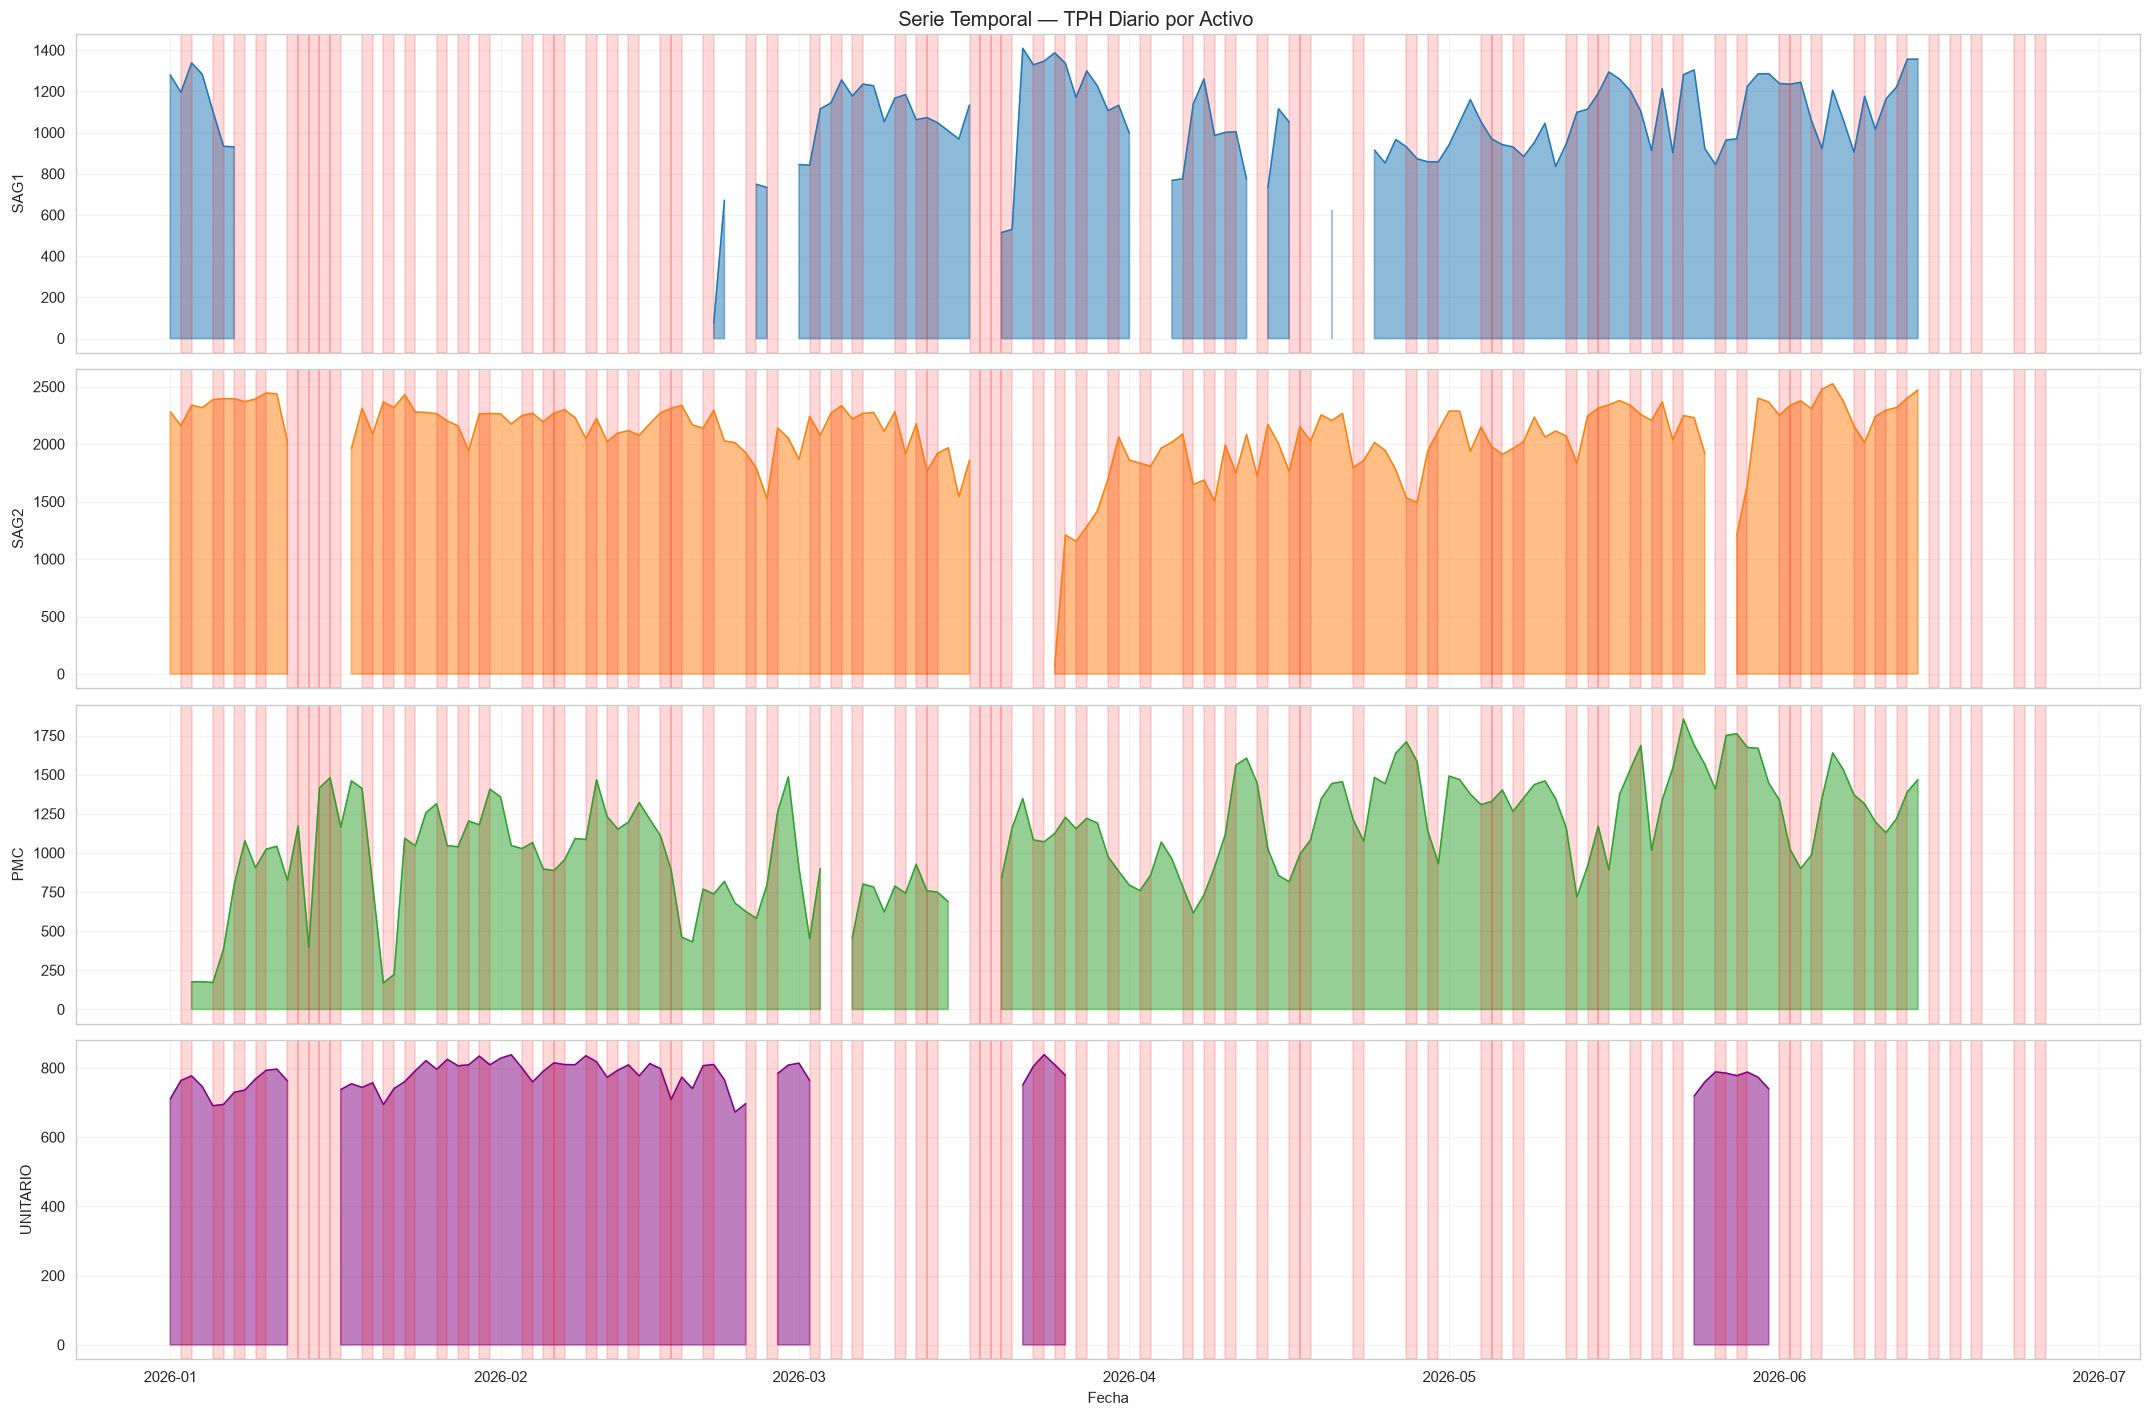

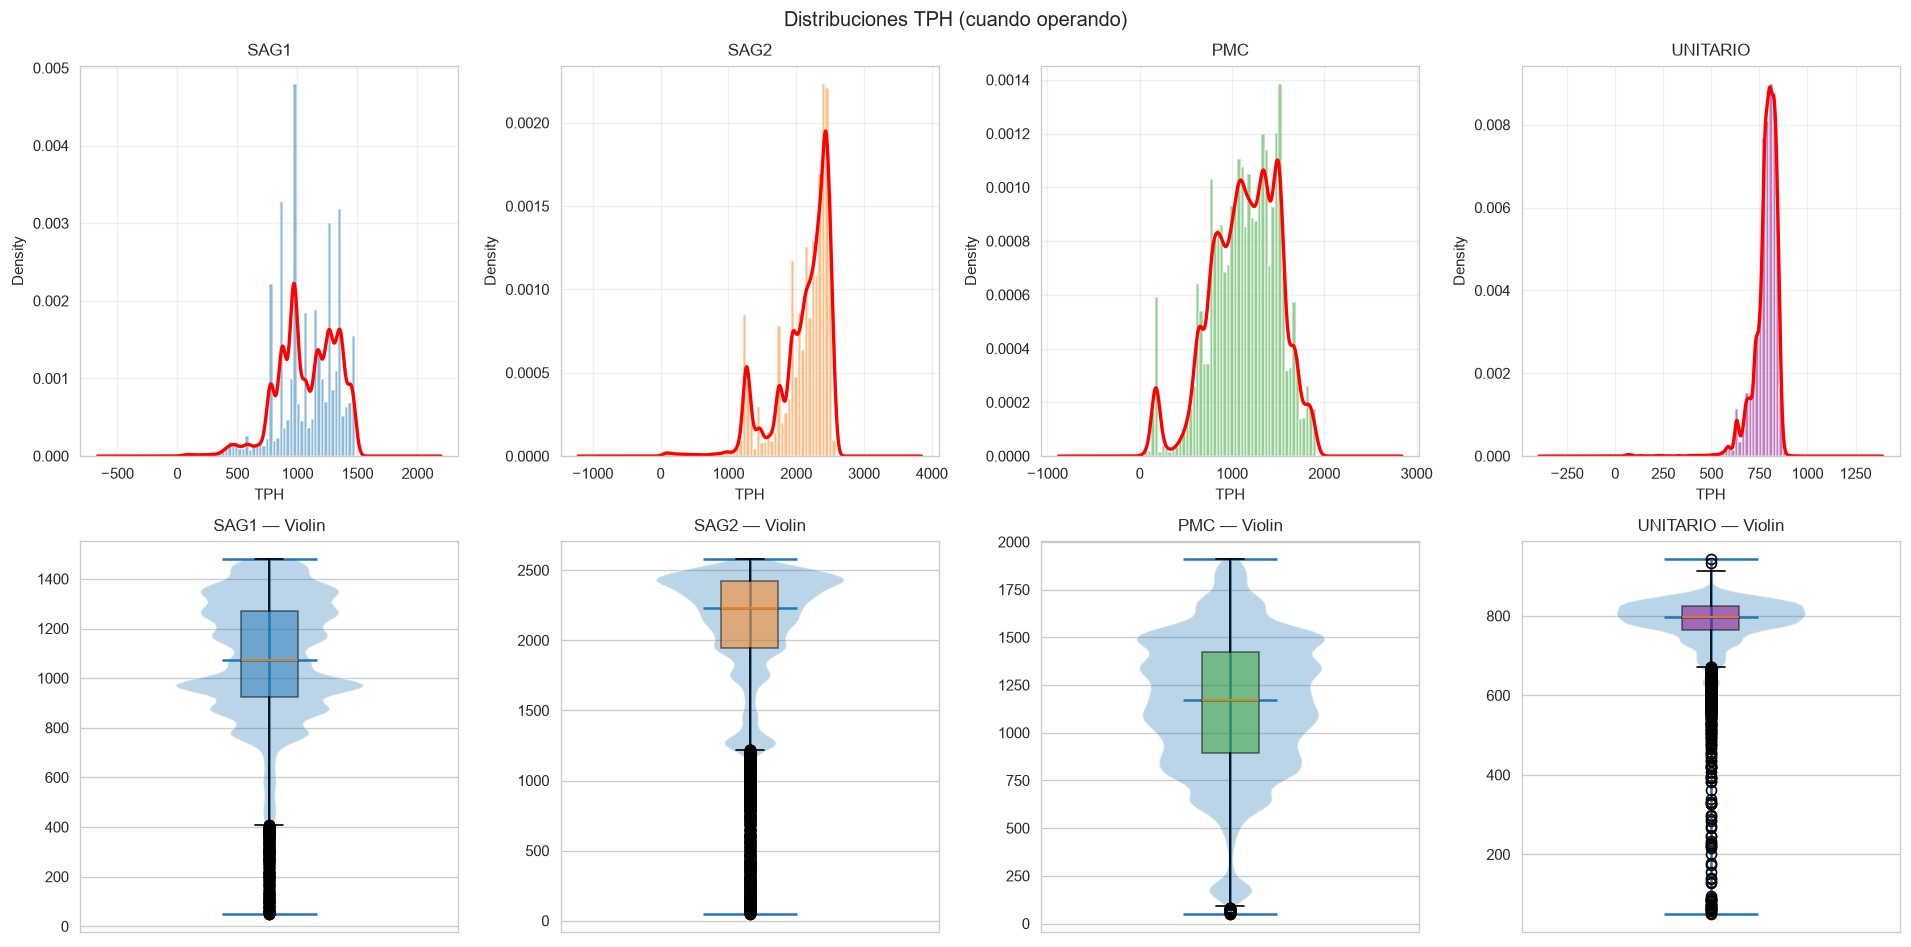

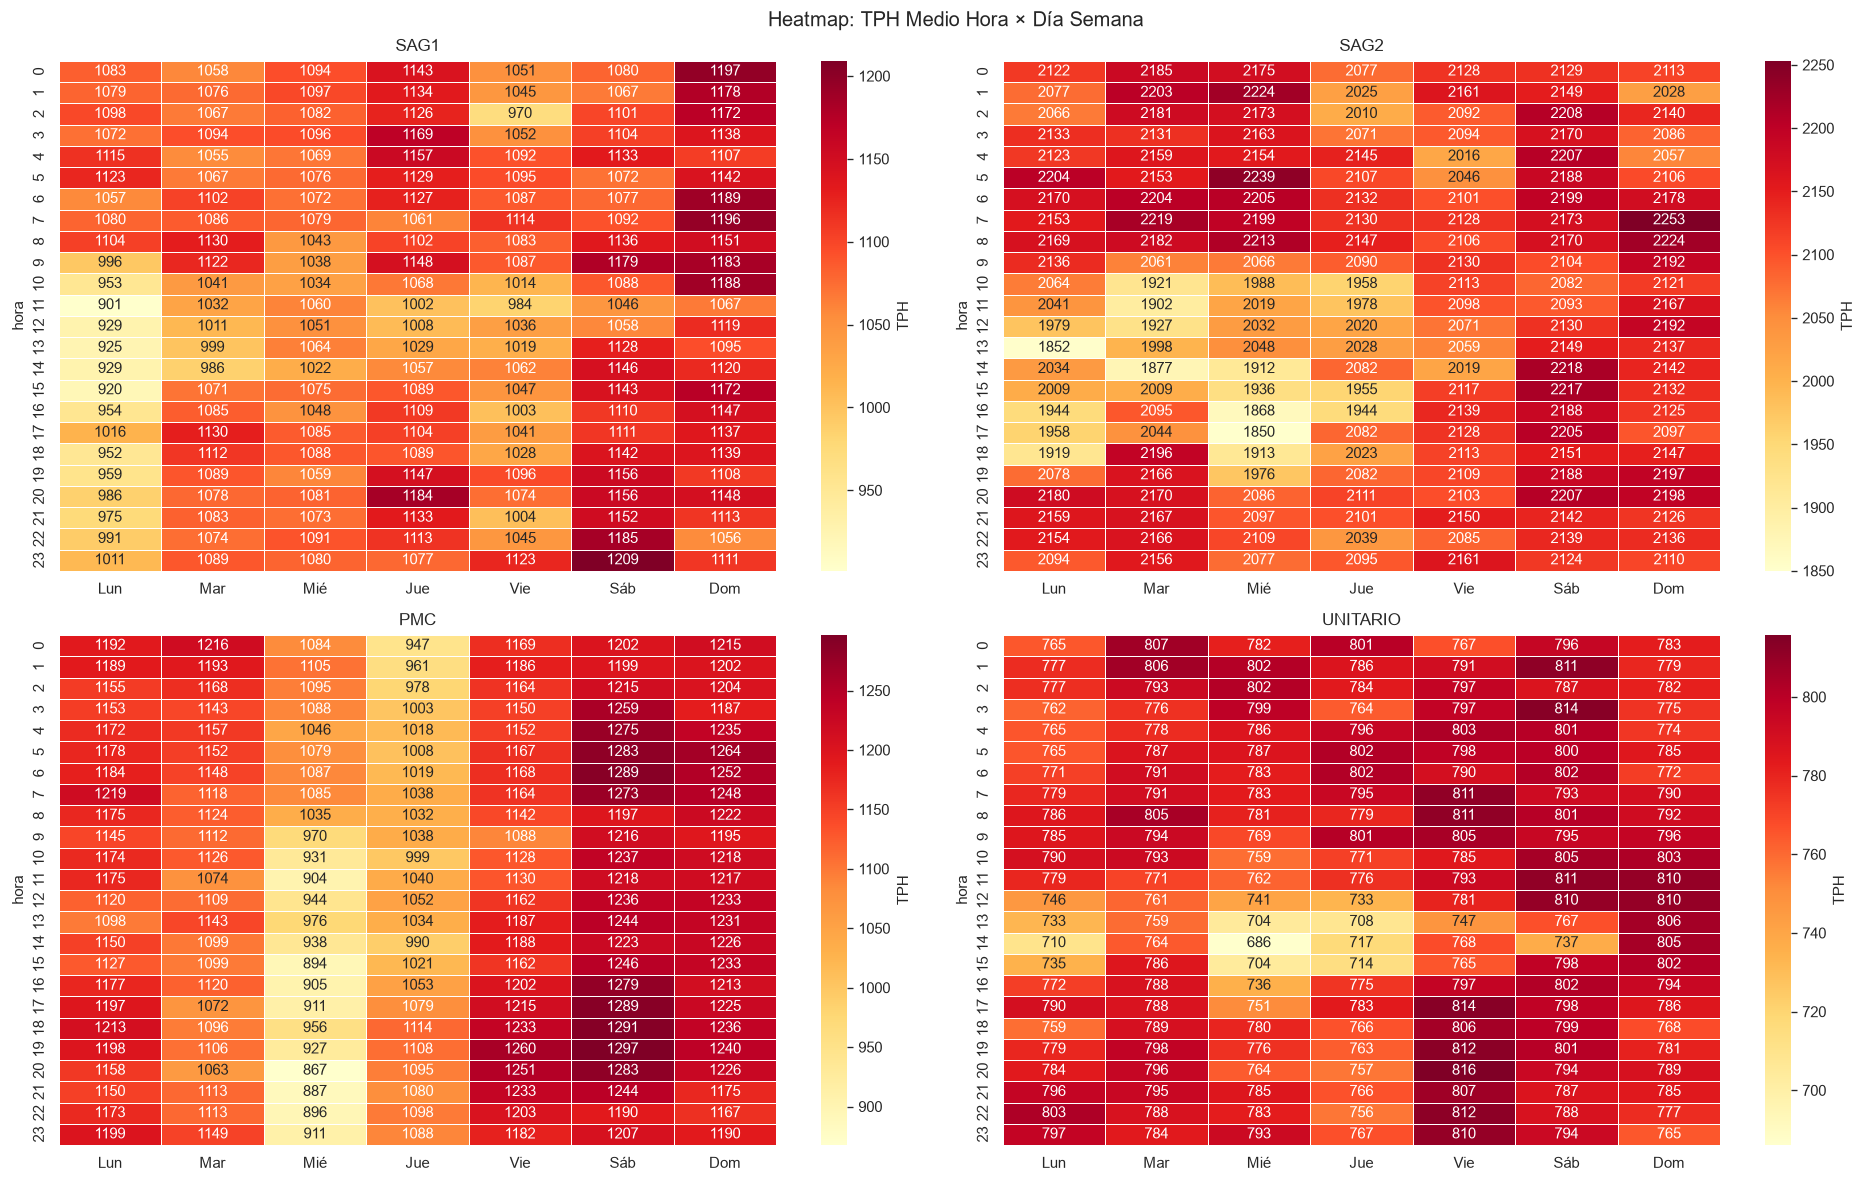

→ 3 figuras EDA generadas


In [9]:
# ── 6.3 Serie temporal + histograma + boxplot ────────────────────────────
DIAS_ES=['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

# Serie temporal diaria
fig,axes=plt.subplots(len(ACTIVOS),1,figsize=(18,3*len(ACTIVOS)),sharex=True)
fig.suptitle('Serie Temporal — TPH Diario por Activo',fontsize=12)
for ax,a in zip(axes,ACTIVOS):
    col=f'{a}_tph_mean'
    s=df_master.set_index('fecha')[col]
    ax.fill_between(s.index,s.values,alpha=0.5,color=COLORES[a])
    ax.plot(s.index,s.values,linewidth=0.8,color=COLORES[a])
    # Marcar ventanas T8
    for _,r in df_t8_raw.iterrows():
        ax.axvspan(r['fecha'],r['fecha']+timedelta(days=1),alpha=0.15,color='red')
    ax.set_ylabel(a,fontsize=9); ax.grid(True,alpha=0.2)
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F01_Serie_Temporal.png',bbox_inches='tight',dpi=120)
plt.show()

# Distribuciones + violin
fig,axes=plt.subplots(2,len(ACTIVOS),figsize=(16,8))
fig.suptitle('Distribuciones TPH (cuando operando)',fontsize=12)
for i,a in enumerate(ACTIVOS):
    s=df_rend.loc[df_rend[f'{a}_operando'],f'{a}_tph']
    axes[0][i].hist(s,bins=50,density=True,alpha=0.5,color=COLORES[a])
    s.plot.kde(ax=axes[0][i],color='red',linewidth=2)
    axes[0][i].set_title(a); axes[0][i].set_xlabel('TPH'); axes[0][i].grid(True,alpha=0.3)
    axes[1][i].violinplot([s.values],showmedians=True)
    axes[1][i].boxplot([s.values],patch_artist=True,boxprops=dict(facecolor=COLORES[a],alpha=0.5))
    axes[1][i].set_title(f'{a} — Violin'); axes[1][i].set_xticks([])
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F02_Distribuciones.png',bbox_inches='tight',dpi=120)
plt.show()

# Heatmap hora × día semana
fig,axes=plt.subplots(2,2,figsize=(16,10))
fig.suptitle('Heatmap: TPH Medio Hora × Día Semana',fontsize=12)
for ax,a in zip(axes.flat,ACTIVOS):
    piv=df_rend.loc[df_rend[f'{a}_operando']].pivot_table(
        values=f'{a}_tph',index='hora',columns='dia_sem',aggfunc='mean')
    piv.columns=[DIAS_ES[c] for c in piv.columns]
    sns.heatmap(piv,ax=ax,cmap='YlOrRd',annot=True,fmt='.0f',linewidths=0.3,cbar_kws={'label':'TPH'})
    ax.set_title(a)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F03_Heatmap.png',bbox_inches='tight',dpi=120)
plt.show(); print('→ 3 figuras EDA generadas')

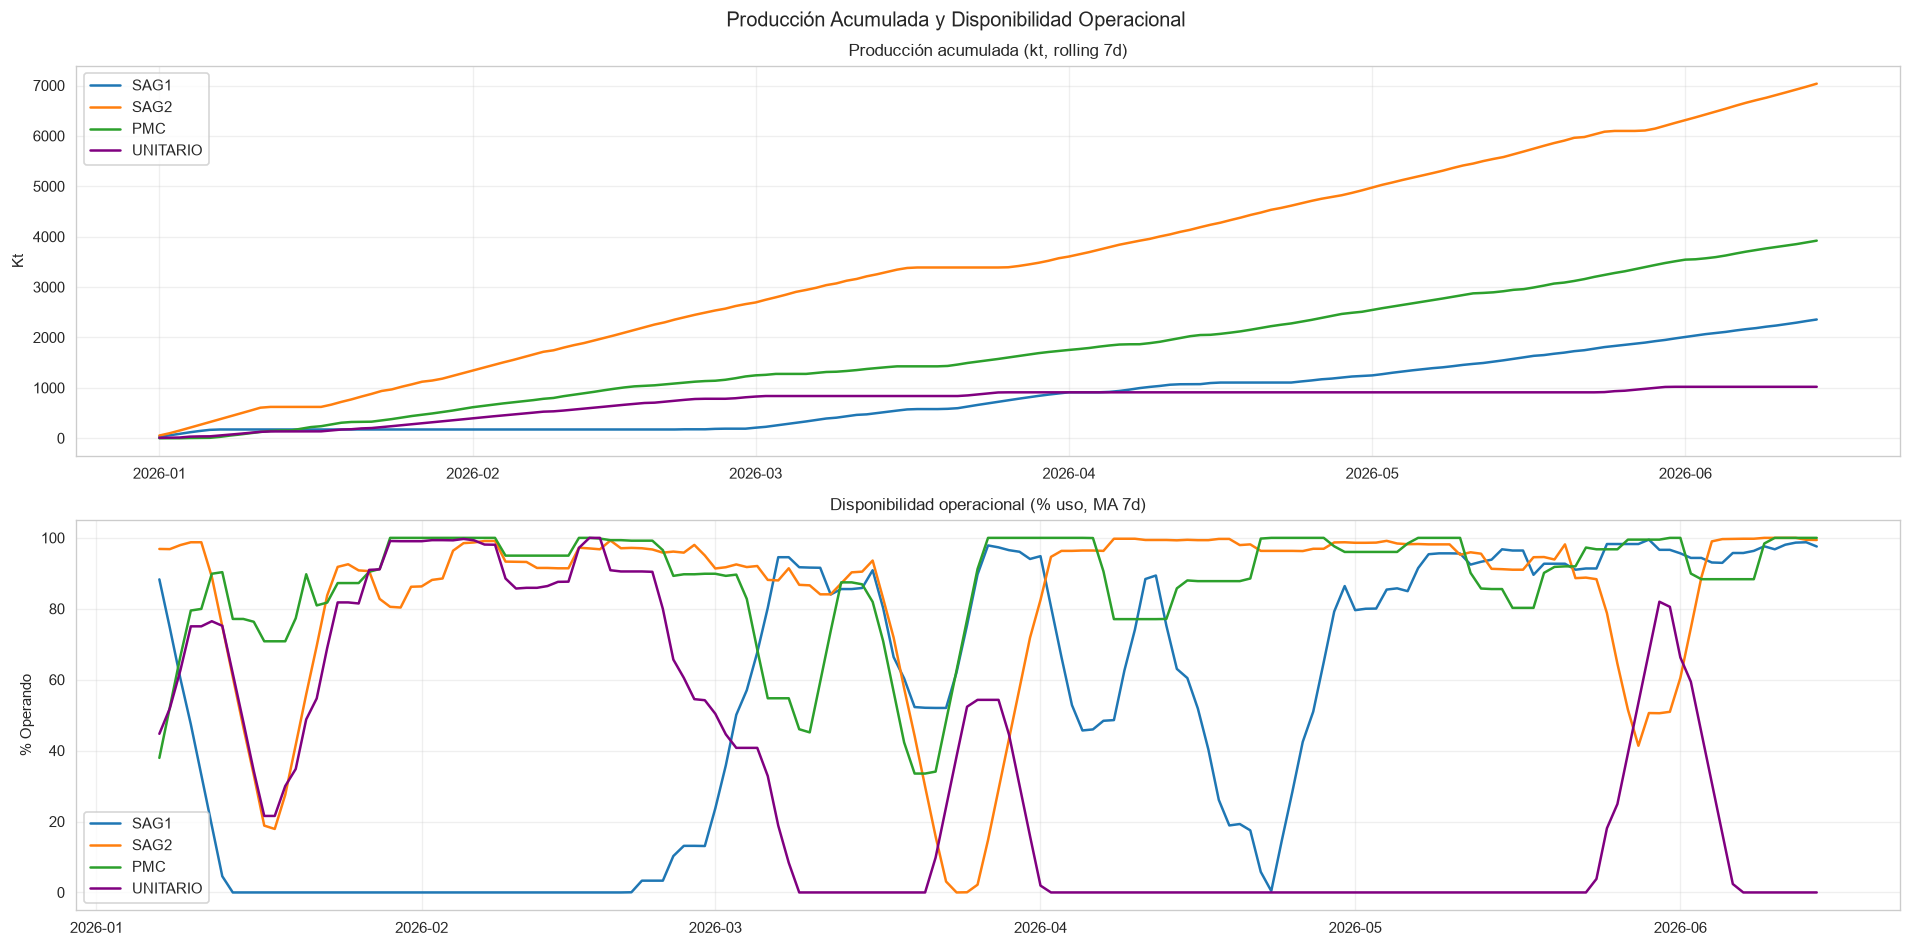

In [10]:
# Producción acumulada + disponibilidad
fig,axes=plt.subplots(2,1,figsize=(16,8))
fig.suptitle('Producción Acumulada y Disponibilidad Operacional',fontsize=12)
for a in ACTIVOS:
    ton_cum=df_master.set_index('fecha')[f'{a}_ton_dia'].cumsum()/1000  # kt
    axes[0].plot(ton_cum.index,ton_cum.values,label=a,color=COLORES[a],linewidth=1.5)
    util=df_master.set_index('fecha')[f'{a}_util_pct'].rolling(7).mean()
    axes[1].plot(util.index,util.values,label=a,color=COLORES[a],linewidth=1.5)
axes[0].set_title('Producción acumulada (kt, rolling 7d)'); axes[0].set_ylabel('Kt')
axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].set_title('Disponibilidad operacional (% uso, MA 7d)'); axes[1].set_ylabel('% Operando')
axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F04_Produccion_Disponibilidad.png',bbox_inches='tight',dpi=120)
plt.show()

---
## 7. Análisis Específico Ventanas T8

COMPARACIÓN POR TIPO DE VENTANA 

── SAG1 ──


,N días,TPH medio,TPH mediana,TPH std,Ton/día,Util%
Tipo ventana,,,,,,
Sin ventana,98,1055.9,1080.4,237.4,15556.4,59.0
Corta 2h,17,1122.5,1174.1,110.1,15049.9,55.7
Media 4h,38,1036.3,1033.6,165.6,14324.8,56.9
Larga 12h,9,680.0,680.0,233.5,2830.3,15.8
Muy larga,3,1134.3,1134.3,NaN,2237.2,8.2



── SAG2 ──


,N días,TPH medio,TPH mediana,TPH std,Ton/día,Util%
Tipo ventana,,,,,,
Sin ventana,98,2101.0,2167.4,269.9,45508.6,89.7
Corta 2h,17,2125.2,2161.3,296.1,46527.7,90.8
Media 4h,38,2023.6,2178.5,434.7,44235.6,88.0
Larga 12h,9,1914.5,1926.0,112.5,10623.1,23.5
Muy larga,3,1859.6,1859.6,NaN,3202.7,7.2



── PMC ──


,N días,TPH medio,TPH mediana,TPH std,Ton/día,Util%
Tipo ventana,,,,,,
Sin ventana,98,1140.5,1165.0,371.9,25549.8,90.1
Corta 2h,17,1067.8,1135.5,265.0,23500.6,88.5
Media 4h,38,1033.7,1027.6,347.3,22053.9,86.6
Larga 12h,9,1042.1,1173.0,385.1,20000.7,72.7
Muy larga,3,NaN,NaN,NaN,0.0,0.0



── UNITARIO ──


,N días,TPH medio,TPH mediana,TPH std,Ton/día,Util%
Tipo ventana,,,,,,
Sin ventana,98,777.3,781.4,39.0,6345.4,33.7
Corta 2h,17,793.8,806.6,29.3,6900.2,36.0
Media 4h,38,770.2,784.0,44.2,6867.5,37.1
Larga 12h,9,749.2,762.4,47.3,2337.4,12.8
Muy larga,3,NaN,NaN,NaN,0.0,0.0


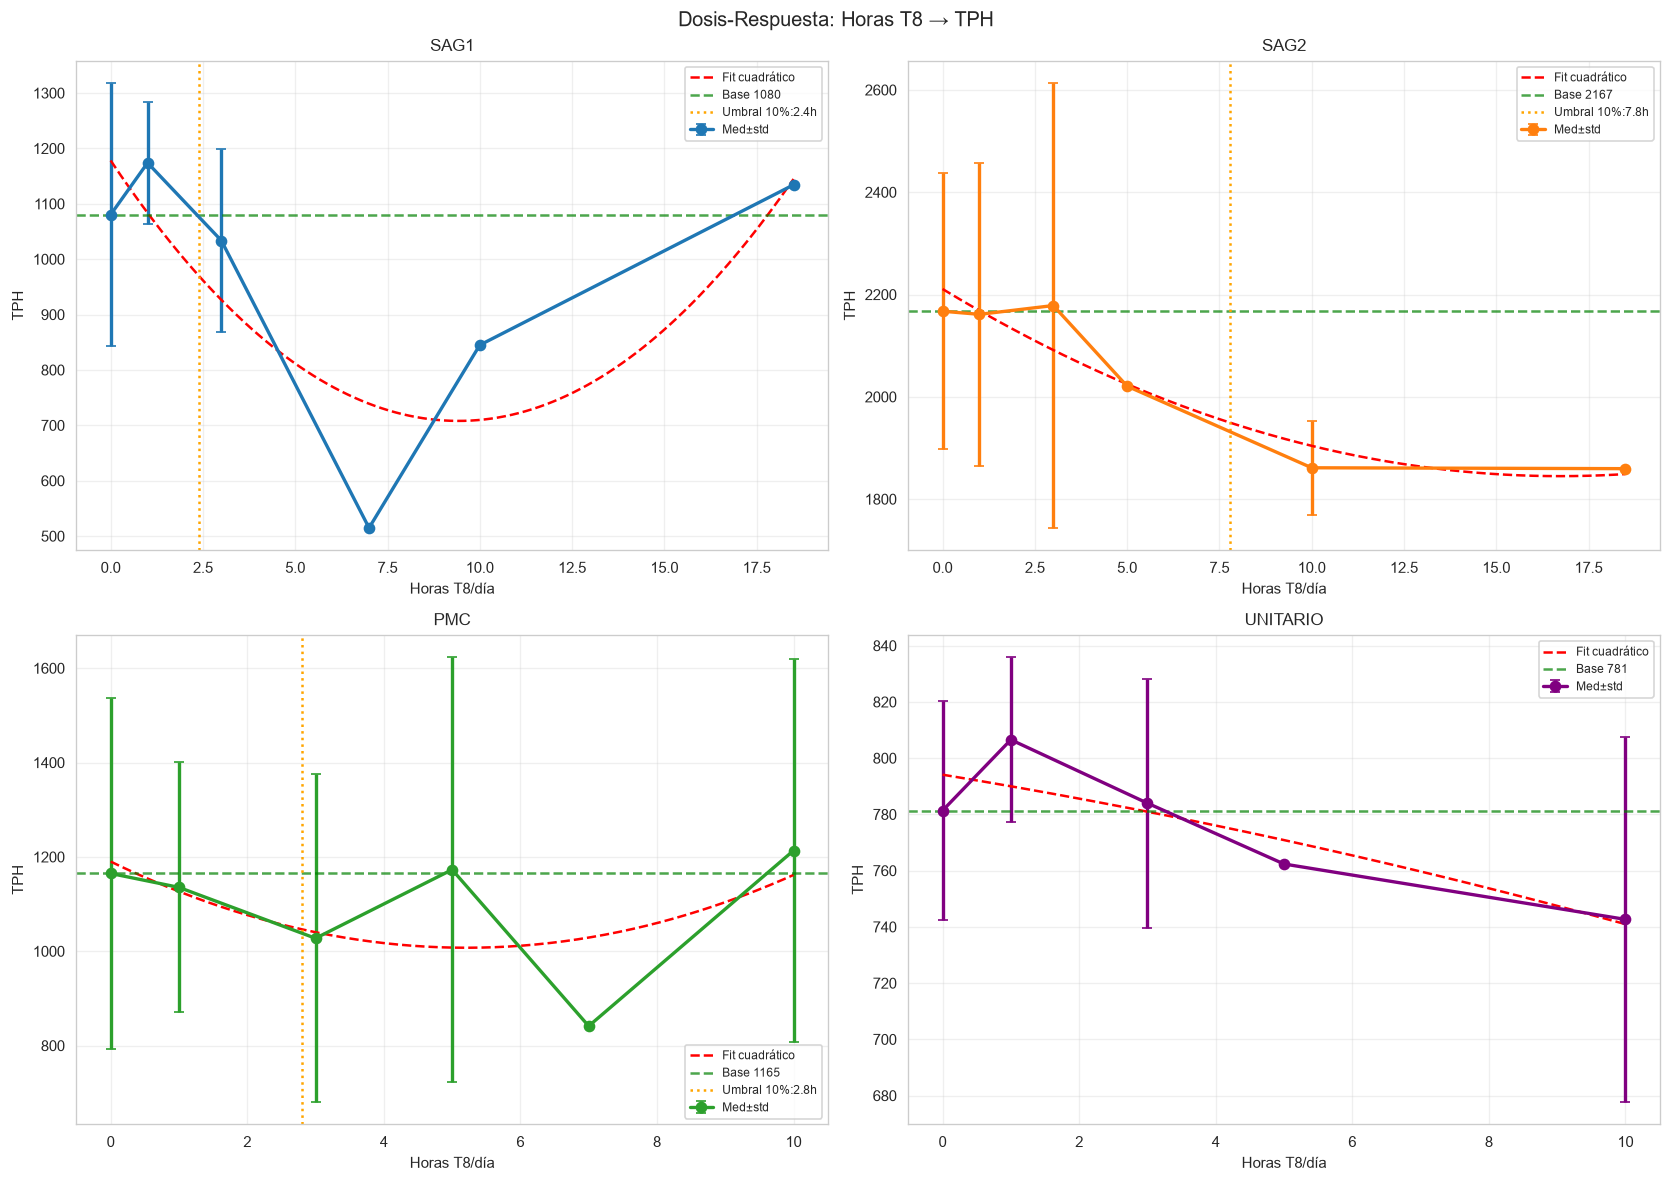

Umbrales críticos (10% caída): {'SAG1': np.float64(2.4), 'SAG2': np.float64(7.8), 'PMC': np.float64(2.8), 'UNITARIO': None}
Elasticidad (OLS): {'SAG1': np.float64(8.166), 'SAG2': np.float64(17.659), 'PMC': np.float64(16.704), 'UNITARIO': np.float64(2.32)}


In [11]:
# skill_molienda_sag + skill_operaciones_mina_subterranea
print('='*70,'\nCOMPARACIÓN POR TIPO DE VENTANA','\n'+'='*70)

# Tabla por tipo de ventana
comp_rows=[]
for a in ACTIVOS:
    for bname in LABELS_T8:
        mask=df_master['tipo_ventana'].astype(str)==bname
        sub=df_master[mask]
        if len(sub)==0: continue
        tph=sub[f'{a}_tph_mean'].dropna()
        ton=sub[f'{a}_ton_dia'].dropna()
        util=sub[f'{a}_util_pct'].dropna()
        comp_rows.append({'Activo':a,'Tipo ventana':bname,'N días':len(sub),
            'TPH medio':tph.mean(),'TPH mediana':tph.median(),'TPH std':tph.std(),
            'Ton/día':ton.mean(),'Util%':util.mean()})
df_comp=pd.DataFrame(comp_rows)

for a in ACTIVOS:
    print(f'\n── {a} ──')
    sub_a=df_comp[df_comp['Activo']==a].set_index('Tipo ventana').drop('Activo',axis=1)
    display(sub_a.round(1))

# Curva dosis-respuesta
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Dosis-Respuesta: Horas T8 → TPH',fontsize=12)
umbrales_criticos={}
elasticidad_bruta={}
for ax,a in zip(axes.flat,ACTIVOS):
    col=f'{a}_tph_mean'
    df_dr=df_master[['horas_t8',col]].dropna()
    base=df_dr.loc[df_dr['horas_t8']==0,col].median()
    df_dr['bin_h']=pd.cut(df_dr['horas_t8'],bins=[-0.001,0,2,4,6,8,12,25],right=True)
    cur=df_dr.groupby('bin_h',observed=True).agg(med=(col,'median'),std=(col,'std'),n=(col,'count')).reset_index()
    cur['mid']=cur['bin_h'].apply(lambda x: x.mid).astype(float); cur=cur.dropna(subset=['med'])
    ax.errorbar(cur['mid'],cur['med'],yerr=cur['std'].fillna(0),fmt='o-',
                color=COLORES[a],capsize=3,linewidth=2,label='Med±std')
    if len(cur)>=3:
        c2=np.polyfit(cur['mid'],cur['med'],2); xf=np.linspace(0,cur['mid'].max(),200)
        ax.plot(xf,np.polyval(c2,xf),'r--',linewidth=1.5,label='Fit cuadrático')
        cr=xf[np.polyval(c2,xf)<base*0.90]
        umbrales_criticos[a]=round(cr[0],1) if len(cr)>0 else None
    m=smf.ols(f'Q("{col}") ~ horas_t8',data=df_dr).fit()
    b1=m.params.get('horas_t8',np.nan)
    elasticidad_bruta[a]={'b1':round(b1,3),'IST8':round(abs(b1),3),'p':round(m.pvalues.get('horas_t8',1),4),'R2':round(m.rsquared,3)}
    ax.axhline(base,color='green',linestyle='--',alpha=0.7,label=f'Base {base:.0f}')
    uc=umbrales_criticos.get(a)
    if uc: ax.axvline(uc,color='orange',linestyle=':',label=f'Umbral 10%:{uc}h')
    ax.set_title(a); ax.set_xlabel('Horas T8/día'); ax.set_ylabel('TPH')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F05_Dosis_Respuesta.png',bbox_inches='tight',dpi=120)
plt.show()
print('Umbrales críticos (10% caída):',umbrales_criticos)
print('Elasticidad (OLS):',{k:v['IST8'] for k,v in elasticidad_bruta.items()})

---
## 8. Análisis Pre / Durante / Post Ventana

In [12]:
# Detectar ventanas continuas
dias_t8=df_master[df_master['horas_t8']>0].sort_values('fecha')
ventanas=[]
if len(dias_t8)>0:
    s,e=dias_t8.iloc[0]['fecha'],dias_t8.iloc[0]['fecha']
    for _,row in dias_t8.iloc[1:].iterrows():
        if (row['fecha']-e).days<=2: e=row['fecha']
        else: ventanas.append({'ini':s,'fin':e}); s,e=row['fecha'],row['fecha']
    ventanas.append({'ini':s,'fin':e})
print(f'Ventanas continuas T8: {len(ventanas)}')
for v in ventanas[:5]: print(f'  {v["ini"].date()} → {v["fin"].date()}')

# Análisis periódico pre/durante/post
def cliffs_delta(x,y):
    x,y=np.asarray(x),np.asarray(y)
    g=(x[:,None]>y[None,:]).sum(); l=(x[:,None]<y[None,:]).sum()
    return (g-l)/(len(x)*len(y))

def cohens_d(x,y):
    nx,ny=len(x),len(y)
    pool=np.sqrt(((nx-1)*np.var(x,ddof=1)+(ny-1)*np.var(y,ddof=1))/(nx+ny-2))
    return (np.mean(x)-np.mean(y))/pool if pool>0 else 0

prepost=[]
for a in ACTIVOS:
    col=f'{a}_tph'; op=f'{a}_operando'
    for n_h in PRE_WINDOWS_HOURS:
        td=timedelta(hours=n_h)
        pre_all,dur_all,post_all=[],[],[]
        for v in ventanas:
            ini,fin=v['ini'],v['fin']+timedelta(days=1)
            pre= df_rend.loc[(df_rend['fecha']>=ini-td)&(df_rend['fecha']<ini)&df_rend[op],col]
            dur= df_rend.loc[(df_rend['fecha']>=ini) &(df_rend['fecha']<fin)&df_rend[op],col]
            post=df_rend.loc[(df_rend['fecha']>=fin) &(df_rend['fecha']<fin+td)&df_rend[op],col]
            pre_all.extend(pre.tolist()); dur_all.extend(dur.tolist()); post_all.extend(post.tolist())
        if len(pre_all)<10 or len(dur_all)<10 or len(post_all)<10: continue
        xp,xd,xq=np.array(pre_all),np.array(dur_all),np.array(post_all)
        d_pct=lambda a,b:(np.mean(b)-np.mean(a))/np.mean(a)*100 if np.mean(a)>0 else np.nan
        prepost.append({'Activo':a,'Ventana h':n_h,
            'TPH pre':round(xp.mean(),1),'TPH durante':round(xd.mean(),1),'TPH post':round(xq.mean(),1),
            'Δ% pre→dur':round(d_pct(xp,xd),2),'Δ% dur→post':round(d_pct(xd,xq),2),
            'Cohen d':round(cohens_d(xp,xd),3),"Cliff δ":round(cliffs_delta(xp,xd),3),
            'Pérd ton(est)':round((xp.mean()-xd.mean())*len(xd)*DT_H,0)})

df_pp=pd.DataFrame(prepost)
print('\nImpacto pre → durante → post:')
display(df_pp.set_index(['Activo','Ventana h']).round(2))

Ventanas continuas T8: 27
  2026-01-02 → 2026-01-02
  2026-01-05 → 2026-01-09
  2026-01-12 → 2026-01-16
  2026-01-19 → 2026-01-23
  2026-01-26 → 2026-01-30



Impacto pre → durante → post:


TPH pre  TPH durante  TPH post  Δ% pre→dur  Δ% dur→post  \
Activo   Ventana h                                                            
SAG1     24          1085.6       1076.7    1107.2       -0.82         2.83   
         48          1090.7       1076.7    1129.7       -1.28         4.92   
         72          1087.2       1076.7    1103.9       -0.97         2.53   
SAG2     24          2091.3       2088.9    2111.1       -0.11         1.06   
         48          2118.8       2088.9    2140.8       -1.41         2.49   
         72          2113.8       2088.9    2120.8       -1.18         1.53   
PMC      24          1162.2       1097.2    1125.7       -5.59         2.59   
         48          1176.7       1097.2    1167.1       -6.75         6.37   
         72          1182.1       1097.2    1164.0       -7.18         6.09   
UNITARIO 24           775.0        781.5     792.4        0.84         1.39   
         48           781.0        781.5     788.6        0.07         0.91   
         72           781.6        781.5     785.1       -0.00         0.46   

                    Cohen d  Cliff δ  Pérd ton(est)  
Activo   Ventana h                                   
SAG1     24            0.04     0.03        10699.0  
         48            0.06     0.06        16801.0  
         72            0.04     0.06        12626.0  
SAG2     24            0.01    -0.03         4238.0  
         48            0.07     0.02        52723.0  
         72            0.06     0.02        43941.0  
PMC      24            0.18     0.15       118735.0  
         48            0.22     0.15       145307.0  
         72            0.24     0.15       155126.0  
UNITARIO 24           -0.09    -0.08        -4690.0  
         48           -0.01    -0.04         -405.0  
         72            0.00    -0.04           24.0

Horas de recuperación promedio:


,h_rec_80pct,h_rec_90pct,h_rec_95pct,h_rec_100pct
Activo,,,,
PMC,0.0,0.0,0.0,0.0
SAG1,0.0,0.0,0.0,0.0
SAG2,0.0,0.0,0.0,0.0
UNITARIO,0.0,0.0,0.0,0.0


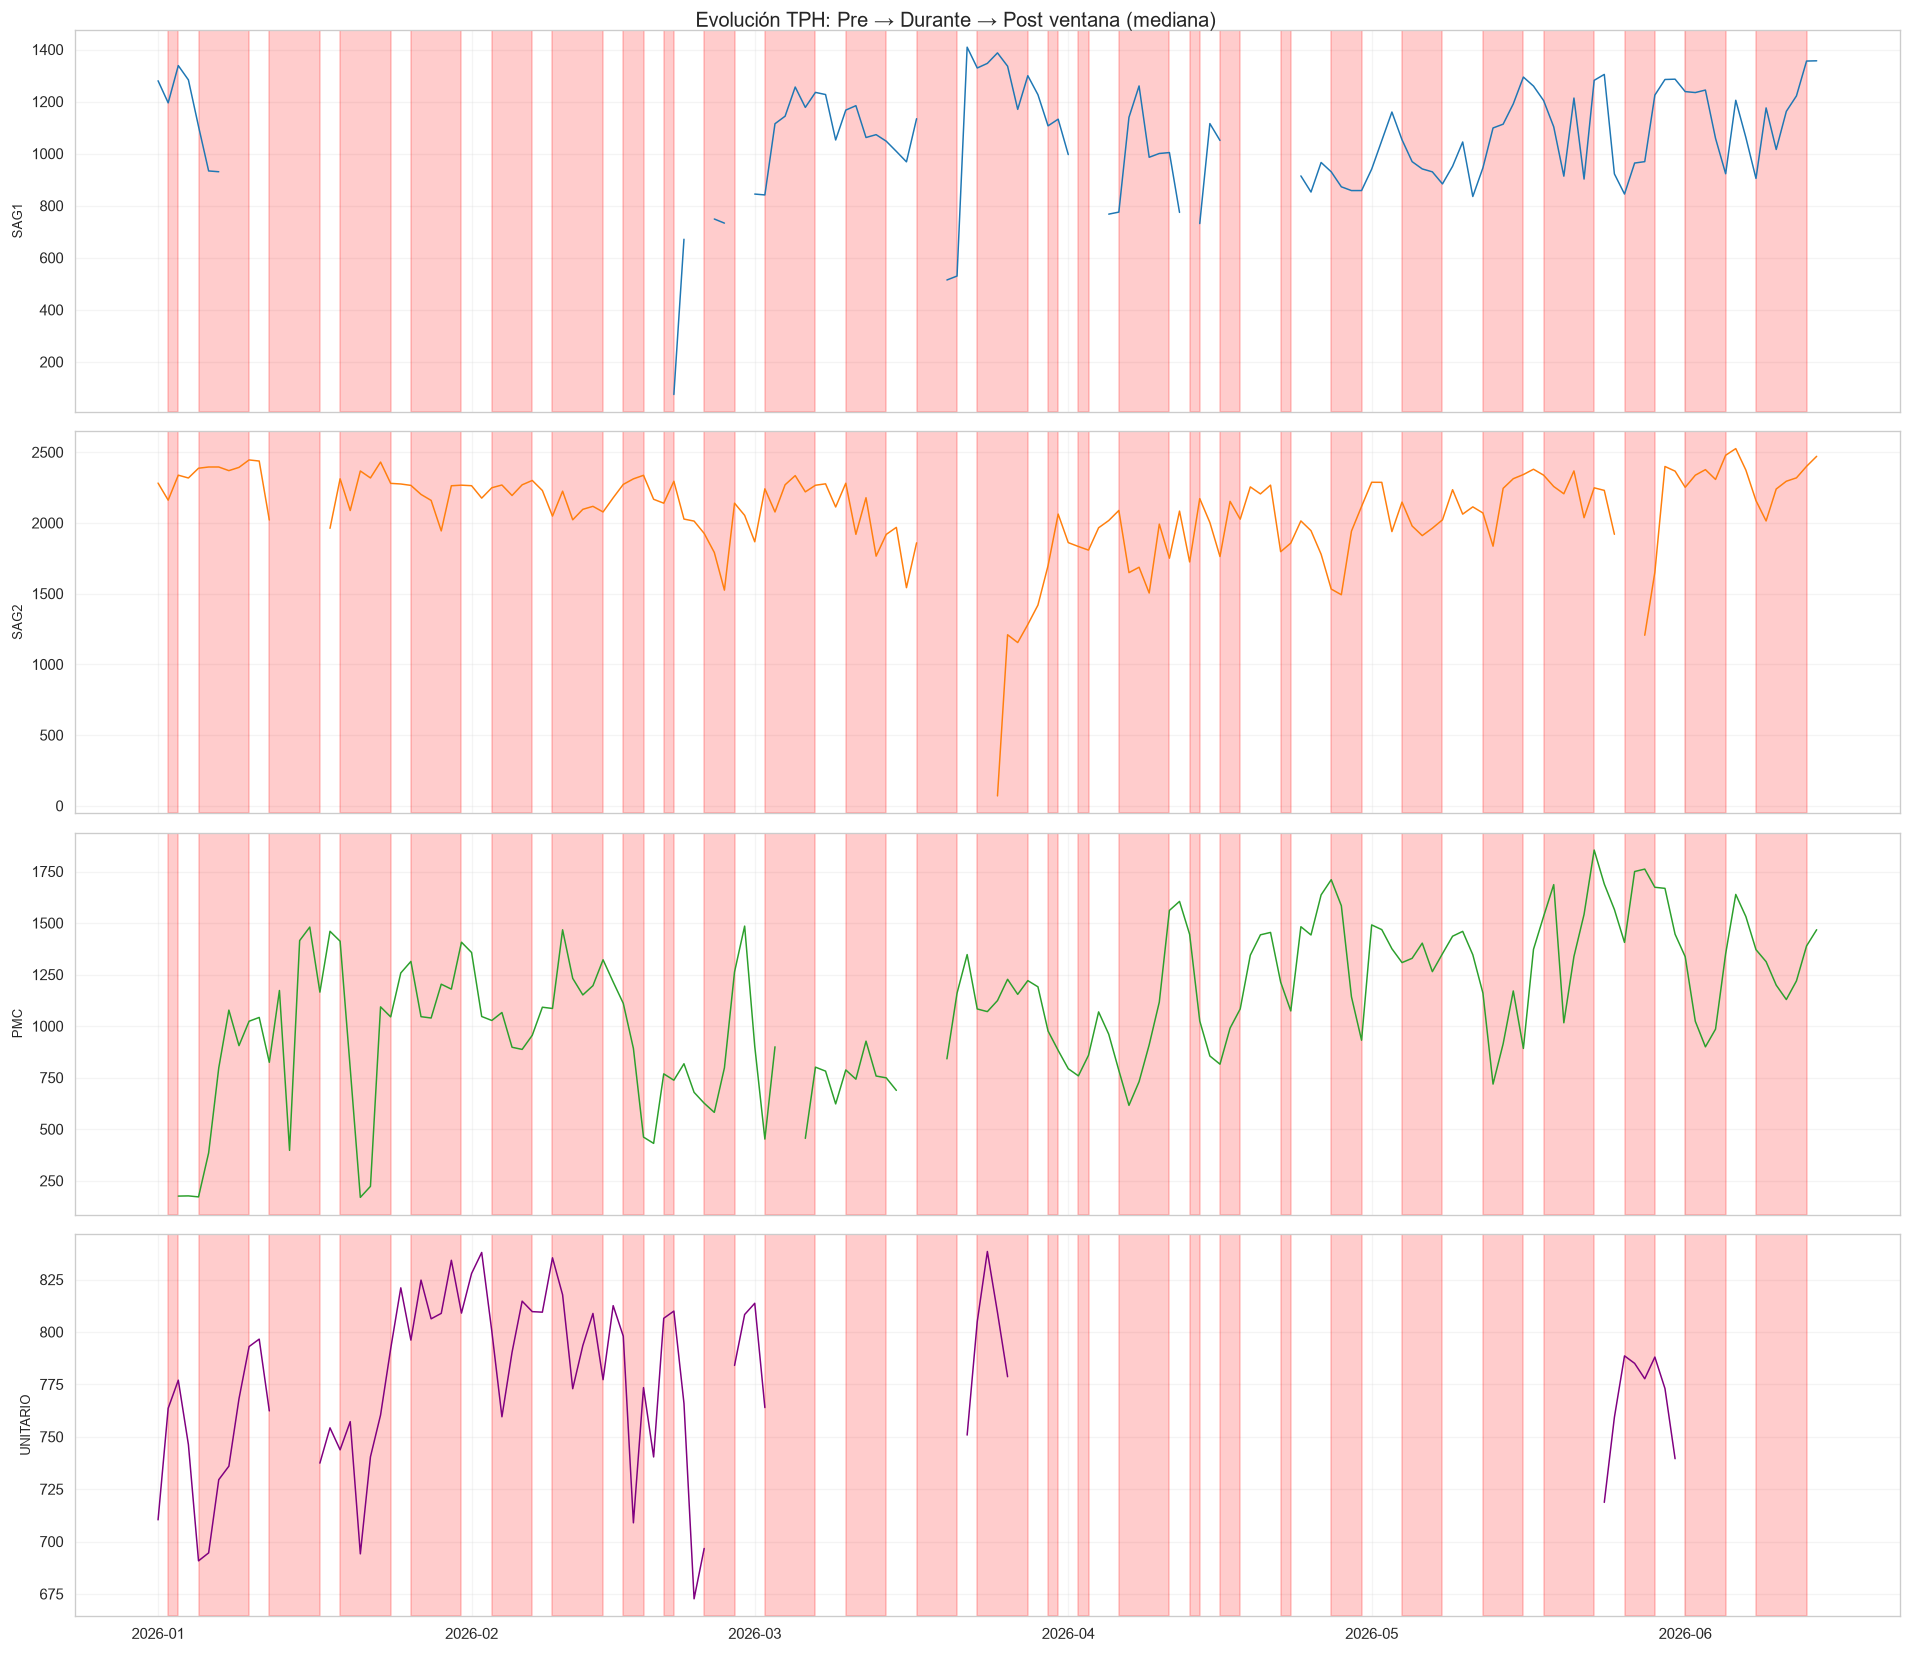

In [13]:
# Tiempos de recuperación
rec_rows=[]
for a in ACTIVOS:
    col=f'{a}_tph'; op=f'{a}_operando'
    for v in ventanas[:min(len(ventanas),25)]:
        ini,fin=v['ini'],v['fin']+timedelta(days=1)
        m_pre=(df_rend['fecha']>=ini-timedelta(hours=48))&(df_rend['fecha']<ini)&df_rend[op]
        base=df_rend.loc[m_pre,col].mean()
        if pd.isna(base) or base<TPH_OPERATIONAL: continue
        m_post=(df_rend['fecha']>=fin)&(df_rend['fecha']<fin+timedelta(hours=120))
        post=df_rend[m_post].reset_index(drop=True)
        roll=post.loc[post[op],col].rolling(12,min_periods=4).mean()
        rec={'Activo':a,'ini':ini.date()}
        for pct in RECOVERY_LEVELS:
            ok=roll[roll>=base*pct].index
            if len(ok)>0:
                h=(df_rend.loc[post.index[ok[0]],'fecha']-fin).total_seconds()/3600
                rec[f'h_rec_{int(pct*100)}pct']=max(0,round(h,1))
            else: rec[f'h_rec_{int(pct*100)}pct']=np.nan
        rec_rows.append(rec)

df_rec=pd.DataFrame(rec_rows)
if not df_rec.empty:
    rec_sum=df_rec.groupby('Activo')[['h_rec_80pct','h_rec_90pct','h_rec_95pct','h_rec_100pct']].mean().round(1)
    print('Horas de recuperación promedio:')
    display(rec_sum)

# Visualización pre/post
fig,axes=plt.subplots(len(ACTIVOS),1,figsize=(16,3.5*len(ACTIVOS)),sharex=True)
fig.suptitle('Evolución TPH: Pre → Durante → Post ventana (mediana)',fontsize=12)
for ax,a in zip(axes,ACTIVOS):
    col=f'{a}_tph_mean'
    s=df_master.set_index('fecha')[col]
    ax.plot(s.index,s.values,color=COLORES[a],linewidth=0.9)
    for v in ventanas:
        ax.axvspan(v['ini'],v['fin']+timedelta(days=1),alpha=0.2,color='red',label='_')
    ax.set_ylabel(a,fontsize=8); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F06_PrePost.png',bbox_inches='tight',dpi=120)
plt.show()

---
## 8b. Monitoreo Visual Pre/Post Ventana T8 - Efecto Gaviota

> Evalua el comportamiento de los rendimientos antes y despues de cada ventana T8
> usando **PAM Mantto** como fuente oficial de fechas y duraciones.

**Script fuente:** `src/efecto_gaviota.py`


In [ ]:
# -- Seccion 8b: Efecto Gaviota inteligente PAM T8 + Series 5-min --------
import sys
sys.path.insert(0, str(BASE_DIR / 'src'))

from efecto_gaviota import run_gaviota_analysis

# PAM Mantto como fuente oficial de eventos T8
# horarios oficiales: 2h=14-16h, 4h=12-16h, 8h=8-16h, 12h=8-20h
resultado_gaviota = run_gaviota_analysis(
    df_rend=df_rend,          # rendimientos 5-min ya cargado en seccion 3
    pam_mantto_dir=None,      # busca en data/raw/PAM_Mantto/
    activos=ACTIVOS,
    top_eventos=8,
    verbose=True,
)

event_results  = resultado_gaviota['eventos']
df_met         = resultado_gaviota['df_met']
gaviota_data   = resultado_gaviota['gaviota_data']
diagnostics    = resultado_gaviota['diagnostics']

# Mostrar figura gaviota SAG1 como preview inline
from IPython.display import Image, display as ipy_display
for fname in ['01_Gaviota_SAG1.png', '05_Gaviota_2h.png', '09_Ranking_Sensibilidad.png']:
    p = BASE_DIR / 'outputs' / 'figures' / 'efecto_gaviota' / fname
    if p.exists():
        print(f'-- {fname} --')
        ipy_display(Image(filename=str(p), width=1000))


In [ ]:
results = run_gaviota_analysis(
    rend_path="../data/raw/Rendimientos/rendimientos_coef - copia.xlsx",
    pam_mantto_dir="../data/raw/PAM_Mantto",
    use_pam_t8_events=True,
    pre_hours=24,
    post_hours=24
)


In [ ]:
results["summary"]


---
## 9. Inferencia Estadística

In [15]:
# skill_estadistica_bayesiana_avanzada + skill_data_scientist_senior
print('='*70,'\nINFERENCIA ESTADÍSTICA','\n'+'='*70)

stat_rows=[]
for a in ACTIVOS:
    col=f'{a}_tph_mean'
    gp={b: df_master.loc[df_master['tipo_ventana'].astype(str)==b,col].dropna().values
        for b in LABELS_T8}
    grupos=[g for g in gp.values() if len(g)>=5]
    g0=gp.get('Sin ventana',np.array([]))
    if len(g0)<5: continue
    for b in ['Corta 2h','Media 4h','Larga 12h']:
        gb=gp.get(b,np.array([]))
        if len(gb)<5: continue
        tt=ttest_ind(g0,gb,equal_var=False)
        mw=mannwhitneyu(g0,gb,alternative='two-sided')
        ks=ks_2samp(g0,gb)
        cd=cohens_d(g0,gb)
        clf=cliffs_delta(g0,gb)
        eta2_val=np.nan
        if len(grupos)>=2:
            ss_b=sum(len(g)*(g.mean()-np.concatenate(grupos).mean())**2 for g in grupos)
            ss_t=np.concatenate(grupos).var(ddof=1)*len(np.concatenate(grupos))
            eta2_val=ss_b/ss_t if ss_t>0 else np.nan
        stat_rows.append({'Activo':a,'Ventana':b,
            'N sin vent':len(g0),'N ventana':len(gb),
            'Media sin':round(g0.mean(),1),'Media vent':round(gb.mean(),1),
            'Δ%':round((gb.mean()-g0.mean())/g0.mean()*100,2) if g0.mean()>0 else np.nan,
            't p':round(tt.pvalue,4),'MW p':round(mw.pvalue,4),'KS p':round(ks.pvalue,4),
            "Cohen's d":round(cd,3),"Cliff's δ":round(clf,3),'Eta²':round(eta2_val,4),
            'Sig':'***' if min(tt.pvalue,mw.pvalue)<0.001 else '**' if min(tt.pvalue,mw.pvalue)<0.01
                  else '*' if min(tt.pvalue,mw.pvalue)<0.05 else 'ns'})

df_stat=pd.DataFrame(stat_rows)
print('Tests t / Mann-Whitney / KS (sin ventana vs cada tipo):')
display(df_stat.set_index(['Activo','Ventana']).round(3))

# Kruskal-Wallis + ANOVA + Tukey para todos los buckets
print('\nKruskal-Wallis y ANOVA por activo (todos los grupos):')
for a in ACTIVOS:
    col=f'{a}_tph_mean'
    grupos_anova=[df_master.loc[df_master['tipo_ventana'].astype(str)==b,col].dropna().values
                  for b in LABELS_T8 if len(df_master.loc[df_master['tipo_ventana'].astype(str)==b,col].dropna())>=5]
    if len(grupos_anova)<2: continue
    kw=kruskal(*grupos_anova); av=f_oneway(*grupos_anova)
    print(f'  {a}: KW p={kw.pvalue:.4f} | ANOVA p={av.pvalue:.4f} | sig:{"***" if kw.pvalue<0.001 else "**" if kw.pvalue<0.01 else "*" if kw.pvalue<0.05 else "ns"}')
    # Tukey
    df_tukey=df_master[['tipo_ventana',col]].dropna()
    if df_tukey['tipo_ventana'].nunique()>=2:
        tukey=pairwise_tukeyhsd(df_tukey[col],df_tukey['tipo_ventana'].astype(str))
        print('    Tukey significativo:',[(r[0],r[1]) for r in tukey.summary().data[1:] if r[6]][:4])

INFERENCIA ESTADÍSTICA 
Tests t / Mann-Whitney / KS (sin ventana vs cada tipo):


N sin vent  N ventana  Media sin  Media vent    Δ%    t p  \
Activo   Ventana                                                                
SAG1     Corta 2h           66         10     1055.9      1122.5  6.31  0.156   
         Media 4h           66         26     1055.9      1036.3 -1.86  0.655   
SAG2     Corta 2h           93         17     2101.0      2125.2  1.15  0.757   
         Media 4h           93         37     2101.0      2023.6 -3.69  0.318   
PMC      Corta 2h           95         16     1140.5      1067.8 -6.37  0.351   
         Media 4h           95         37     1140.5      1033.7 -9.36  0.124   
         Larga 12h          95          9     1140.5      1042.1 -8.63  0.480   
UNITARIO Corta 2h           42          7      777.3       793.8  2.13  0.219   
         Media 4h           42         16      777.3       770.2 -0.91  0.578   

                     MW p   KS p  Cohen's d  Cliff's δ   Eta² Sig  
Activo   Ventana                                                   
SAG1     Corta 2h   0.564  0.367     -0.295     -0.115  0.012  ns  
         Media 4h   0.384  0.384      0.089      0.118  0.012  ns  
SAG2     Corta 2h   0.626  0.284     -0.088     -0.075  0.013  ns  
         Media 4h   0.602  0.794      0.238      0.059  0.013  ns  
PMC      Corta 2h   0.320  0.070      0.202      0.157  0.018  ns  
         Media 4h   0.091  0.081      0.292      0.190  0.018  ns  
         Larga 12h  0.488  0.674      0.264      0.142  0.018  ns  
UNITARIO Corta 2h   0.376  0.373     -0.436     -0.218  0.027  ns  
         Media 4h   0.560  0.616      0.175      0.101  0.027  ns


Kruskal-Wallis y ANOVA por activo (todos los grupos):
  SAG1: KW p=0.4082 | ANOVA p=0.5505 | sig:ns


    Tukey significativo: []


  SAG2: KW p=0.7471 | ANOVA p=0.4002 | sig:ns
    Tukey significativo: []


  PMC: KW p=0.3164 | ANOVA p=0.4189 | sig:ns
    Tukey significativo: []
  UNITARIO: KW p=0.4790 | ANOVA p=0.4241 | sig:ns


    Tukey significativo: []


---
## 10. Series de Tiempo

In [16]:
# skill_series_temporales_industriales
print('='*70,'\nSTL DECOMPOSITION','\n'+'='*70)

fig,axes=plt.subplots(len(ACTIVOS),4,figsize=(18,3.5*len(ACTIVOS)))
fig.suptitle('STL Descomposición — TPH Diario (period=7)',fontsize=12)
stl_res={}
for ri,a in enumerate(ACTIVOS):
    col=f'{a}_tph_mean'
    s=df_master.set_index('fecha')[col].asfreq('D').ffill().dropna()
    if len(s)<21: [axes[ri][ci].axis('off') for ci in range(4)]; continue
    stl=STL(s,period=7,robust=True).fit(); stl_res[a]=stl
    for ci,(comp,lbl) in enumerate([(s,'Original'),(stl.trend,'Tendencia'),
                                     (stl.seasonal,'Estacional'),(stl.resid,'Residuo')]):
        axes[ri][ci].plot(comp.index,comp.values,linewidth=0.8,color=COLORES[a])
        axes[ri][ci].set_title(f'{a}—{lbl}',fontsize=9); axes[ri][ci].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F07_STL.png',bbox_inches='tight',dpi=120)
plt.show()

# ADF + KPSS
print('Estacionariedad (ADF + KPSS):')
est_rows=[]
for a in ACTIVOS:
    col=f'{a}_tph_mean'
    s=df_master[col].dropna().values
    if len(s)<20: continue
    adf=adfuller(s,autolag='AIC')
    try: kp=kpss(s,regression='c',nlags='auto')
    except: kp=(np.nan,np.nan,np.nan,{})
    est_rows.append({'Activo':a,'ADF stat':adf[0],'ADF p':adf[1],'ADF estac':adf[1]<0.05,
        'KPSS stat':kp[0],'KPSS p':kp[1],'KPSS estac':kp[1]>0.05 if not np.isnan(kp[1]) else None,
        'Conclusión': 'Estacionaria' if (adf[1]<0.05 and kp[1]>0.05) else
                     'No estacionaria' if (adf[1]>=0.05 and kp[1]<=0.05) else 'Revisar'})
df_est=pd.DataFrame(est_rows).set_index('Activo')
display(df_est.round(4))

STL DECOMPOSITION 


Estacionariedad (ADF + KPSS):


,ADF stat,ADF p,ADF estac,KPSS stat,KPSS p,KPSS estac,Conclusión
Activo,,,,,,,
SAG1,-4.3284,0.0004,True,0.1741,0.10,True,Estacionaria
SAG2,-3.9220,0.0019,True,0.3251,0.10,True,Estacionaria
PMC,-5.4393,0.0000,True,1.0990,0.01,False,Revisar
UNITARIO,-4.4468,0.0002,True,0.3027,0.10,True,Estacionaria


In [17]:
# ACF / PACF
fig,axes=plt.subplots(2,len(ACTIVOS),figsize=(18,8))
fig.suptitle('ACF y PACF — TPH Diario (lags 0-30)',fontsize=12)
for ci,a in enumerate(ACTIVOS):
    s=df_master[f'{a}_tph_mean'].dropna()
    lgs=min(30,len(s)//2-1)
    if len(s)>10:
        plot_acf(s,ax=axes[0][ci],lags=lgs,title=f'ACF {a}',color=COLORES[a])
        plot_pacf(s,ax=axes[1][ci],lags=lgs,title=f'PACF {a}',color=COLORES[a],method='ywm')
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F08_ACF_PACF.png',bbox_inches='tight',dpi=120)
plt.show()

# ── Change points ─────────────────────────────────────────────────────────
print('Change Points por activo:')
cp_rows=[]
fig,axes=plt.subplots(len(ACTIVOS),1,figsize=(16,3*len(ACTIVOS)),sharex=True)
fig.suptitle('Change Points — TPH Diario',fontsize=12)
for ax,a in zip(axes,ACTIVOS):
    col=f'{a}_tph_mean'
    s=df_master.set_index('fecha')[col].ffill().dropna()
    # Rolling z-score
    roll_m=s.rolling(14,min_periods=7).mean()
    roll_s=s.rolling(14,min_periods=7).std()
    z=(s-roll_m)/(roll_s+1e-9)
    cp_z=s.index[np.abs(z.values)>2.5]
    # ruptures si disponible
    cp_r=[]
    if TIENE_RUPTURES and len(s)>30:
        try:
            algo=rpt.Pelt(model='rbf',min_size=7).fit(s.values)
            cp_r=[s.index[i] for i in algo.predict(pen=5)[:-1] if i<len(s)]
        except: pass
    cp_rows.append({'Activo':a,'CP z-score':len(cp_z),'CP ruptures':len(cp_r)})
    ax.plot(s.index,s.values,color=COLORES[a],linewidth=0.9)
    for cp in cp_z[:15]: ax.axvline(cp,color='red',alpha=0.4,linewidth=0.8)
    for cp in cp_r[:5]: ax.axvline(cp,color='black',alpha=0.7,linewidth=1.2,linestyle='--')
    ax.set_ylabel(a,fontsize=8); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F09_ChangePoints.png',bbox_inches='tight',dpi=120)
plt.show()
display(pd.DataFrame(cp_rows).set_index('Activo'))

Change Points por activo:


,CP z-score,CP ruptures
Activo,,
SAG1,2,2
SAG2,3,2
PMC,4,2
UNITARIO,6,4


---
## 11. Modelo de Consumo de Pilas

In [18]:
# skill_operaciones_mina_subterranea: pila SAG ~36h, Conv ~18h
print('='*70,'\nÍNDICE DE CONSUMO DE PILAS','\n'+'='*70)

GRUPOS_PILA={'SAG':['SAG1','SAG2'],'Conv':['PMC','UNITARIO']}
tasa_base={a:df_rend.loc[df_rend[f'{a}_operando'],f'{a}_tph'].median() for a in ACTIVOS}
print('Tasa base mediana (cuando operando):', {k:round(v,0) for k,v in tasa_base.items()})

pila_rows=[]
for v in ventanas:
    ini=v['ini']; fin=v['fin']+timedelta(days=1)
    dur_h=(fin-ini).total_seconds()/3600
    t0=ini-timedelta(hours=48); t1=fin+timedelta(hours=72)
    sub=df_rend[(df_rend['fecha']>=t0)&(df_rend['fecha']<t1)].reset_index(drop=True)
    if sub.empty: continue
    en_v=(sub['fecha']>=ini)&(sub['fecha']<fin)
    for grupo,acts in GRUPOS_PILA.items():
        tph_real=sum(sub[f'{a}_tph'].fillna(0) for a in acts)
        tph_alim=sum(tasa_base[a] for a in acts)
        # Durante ventana: alimentación=0; antes/después: normal
        entrada=tph_alim*(~en_v).astype(float)*DT_H
        salida=tph_real*DT_H
        delta=(entrada-salida).values
        stock=np.cumsum(delta)
        rng=stock.max()-stock.min()
        idx_norm=(stock-stock.min())/rng*100 if rng>0 else np.full_like(stock,50.0)
        idx_v=idx_norm[en_v.values]
        tasa_agt=np.polyfit(range(len(idx_v)),idx_v,1)[0] if len(idx_v)>1 else np.nan
        low=np.where(idx_v<20)[0]
        h_agot=low[0]*DT_H if len(low)>0 else np.nan
        # Índice de Vulnerabilidad de Pila
        col_a=f'{acts[0]}_tph_mean'
        caida_tph=df_master.loc[df_master['fecha']==ini.normalize(),col_a].values
        tph_base=tasa_base[acts[0]]
        delta_tph=tph_base-caida_tph[0] if len(caida_tph)>0 else np.nan
        ivp=delta_tph/tph_alim/dur_h if (tph_alim>0 and dur_h>0 and not np.isnan(delta_tph)) else np.nan
        pila_rows.append({'ventana_ini':ini.date(),'grupo':grupo,'dur_h':round(dur_h,1),
            'tasa_agt_pct/per':round(tasa_agt,3) if not np.isnan(tasa_agt) else np.nan,
            'h_agot_20pct':round(h_agot,1) if not np.isnan(h_agot) else np.nan,
            'stock_min':round(idx_v.min(),1) if len(idx_v)>0 else np.nan,
            'IVP':round(ivp,4) if not np.isnan(ivp) else np.nan})

df_pila=pd.DataFrame(pila_rows)
if not df_pila.empty:
    resumen_pila=df_pila.groupby('grupo').agg(
        tasa_agt_media=('tasa_agt_pct/per','mean'),
        h_agot_mediana=('h_agot_20pct','median'),
        stock_min_media=('stock_min','mean'),
        IVP_medio=('IVP','mean')).round(3)
    display(resumen_pila)
    print('\nPor duración ventana:')
    df_pila['dur_cat']=pd.cut(df_pila['dur_h'],bins=[0,4,12,100],labels=['<4h','4-12h','>12h'])
    display(df_pila.groupby(['grupo','dur_cat'],observed=True)['h_agot_20pct'].median().round(1))

ÍNDICE DE CONSUMO DE PILAS 
Tasa base mediana (cuando operando): {'SAG1': np.float64(1074.0), 'SAG2': np.float64(2234.0), 'PMC': np.float64(1171.0), 'UNITARIO': np.float64(797.0)}


,tasa_agt_media,h_agot_mediana,stock_min_media,IVP_medio
grupo,,,,
Conv,-0.086,77.40,8.500,0.001
SAG,-0.112,75.85,3.356,0.000



Por duración ventana:


grupo  dur_cat
Conv   >12h       65.1
SAG    >12h       46.2
Name: h_agot_20pct, dtype: float64

---
## 12. Modelos Predictivos

In [19]:
# skill_machine_learning_operacional: TimeSeriesSplit, no KFold
print('='*70,'\nFEATURE ENGINEERING','\n'+'='*70)

# Features 5-min sobre df_rend
for a in ACTIVOS:
    s=df_rend[f'{a}_tph']
    for lag in [1,6,12,24,48,288]:
        df_rend[f'{a}_lag{lag}']=s.shift(lag)
    for w in [12,48,288]:
        df_rend[f'{a}_roll{w}m']=s.rolling(w,min_periods=4).mean()
        df_rend[f'{a}_std{w}m']=s.rolling(w,min_periods=4).std()

df_rend['hora_sin']=np.sin(2*np.pi*df_rend['hora']/24)
df_rend['hora_cos']=np.cos(2*np.pi*df_rend['hora']/24)

# Merge con features T8
t8_feats=['fecha','horas_t8','horas_t8_lag1','horas_t8_lag2','horas_t8_lag3','horas_t8_roll3d','horas_t8_roll7d']
df_ml=df_rend.merge(df_master[t8_feats].rename(columns={'fecha':'fecha_dia_t8'}),
                    left_on='fecha_dia',right_on='fecha_dia_t8',how='left').drop(columns=['fecha_dia_t8'],errors='ignore')
# Agregar indice_pila (diario, interpolado)
if not df_pila.empty:
    pila_sag=df_pila[df_pila['grupo']=='SAG'][['ventana_ini','stock_min']].rename(
        columns={'ventana_ini':'fecha','stock_min':'indice_pila_sag'})
    pila_sag['fecha']=pd.to_datetime(pila_sag['fecha'])
    df_ml=df_ml.merge(pila_sag,left_on='fecha_dia',right_on='fecha',how='left').drop(columns='fecha_y',errors='ignore')
    df_ml['indice_pila_sag']=df_ml['indice_pila_sag'].fillna(100)

BASE_FEATS=['hora_sin','hora_cos','dia_sem','mes','horas_t8','horas_t8_lag1','horas_t8_lag2','horas_t8_lag3','horas_t8_roll3d']

def evaluar(y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)
    mape=np.mean(np.abs((y_true-y_pred)/(np.abs(y_true)+1)))*100
    return {'MAE':round(mae,1),'RMSE':round(rmse,1),'R2':round(r2,3),'MAPE%':round(mape,1)}

TSCV=TimeSeriesSplit(n_splits=3)
ml_res=[]; best_models={}; champion={}

for a in ACTIVOS:
    col=f'{a}_tph'; op=f'{a}_operando'
    feat_cols=BASE_FEATS.copy()
    feat_cols+=[f'{a}_lag{l}' for l in [1,6,12,24,48,288] if f'{a}_lag{l}' in df_ml.columns]
    feat_cols+=[f'{a}_roll{w}m' for w in [12,48,288] if f'{a}_roll{w}m' in df_ml.columns]
    feat_cols+=[f'{a}_std{w}m' for w in [12,48] if f'{a}_std{w}m' in df_ml.columns]
    if 'indice_pila_sag' in df_ml.columns and a in ['SAG1','SAG2']: feat_cols.append('indice_pila_sag')
    feat_cols=[f for f in feat_cols if f in df_ml.columns]
    df_a=df_ml.loc[df_ml[op],feat_cols+[col]].dropna()
    if len(df_a)<500: continue
    X,y=df_a[feat_cols],df_a[col]
    models_list=[('RF',RandomForestRegressor(n_estimators=100,max_depth=8,n_jobs=-1,random_state=42))]
    if TIENE_XGB: import xgboost as xgb; models_list.append(('XGB',xgb.XGBRegressor(n_estimators=150,max_depth=6,verbosity=0,n_jobs=-1,random_state=42)))
    if TIENE_LGB: import lightgbm as lgb; models_list.append(('LGB',lgb.LGBMRegressor(n_estimators=150,max_depth=6,verbose=-1,n_jobs=-1,random_state=42)))
    if TIENE_CAT: import catboost as cb; models_list.append(('CAT',cb.CatBoostRegressor(iterations=150,max_depth=6,verbose=0,random_seed=42)))
    best_r2=-999; best_name=None
    for name,model in models_list:
        folds=[]
        for tr,val in TSCV.split(X):
            model.fit(X.iloc[tr],y.iloc[tr])
            folds.append(evaluar(y.iloc[val].values,model.predict(X.iloc[val])))
        met=pd.DataFrame(folds).mean().to_dict()
        ml_res.append({'Activo':a,'Modelo':name,**met})
        print(f'  {a} {name}: MAE={met["MAE"]:.1f} R²={met["R2"]:.3f}')
        if met['R2']>best_r2: best_r2=met['R2']; best_name=name; best_mod=model
    best_mod.fit(X,y)
    best_models[a]={'model':best_mod,'feats':feat_cols,'X':X,'y':y}
    champion[a]={'nombre':best_name,'R2':round(best_r2,3)}

df_ml_res=pd.DataFrame(ml_res)
print('\nComparación R² (cross-val):')
if not df_ml_res.empty:
    display(df_ml_res.pivot_table(index='Modelo',columns='Activo',values='R2',aggfunc='mean').round(3))
print('\nModelo campeón:',champion)

FEATURE ENGINEERING 


  SAG1 RF: MAE=26.6 R²=0.912


  SAG1 XGB: MAE=36.6 R²=0.893


  SAG1 LGB: MAE=26.7 R²=0.919


  SAG1 CAT: MAE=30.1 R²=0.917


...

  UNITARIO LGB: MAE=13.5 R²=0.599


  UNITARIO CAT: MAE=16.2 R²=0.580



Comparación R² (cross-val):


Activo,PMC,SAG1,SAG2,UNITARIO
Modelo,,,,
CAT,0.942,0.917,0.909,0.580
LGB,0.958,0.919,0.917,0.599
RF,0.958,0.912,0.912,0.608
XGB,0.946,0.893,0.856,0.181



Modelo campeón: {'SAG1': {'nombre': 'LGB', 'R2': 0.919}, 'SAG2': {'nombre': 'LGB', 'R2': 0.917}, 'PMC': {'nombre': 'LGB', 'R2': 0.958}, 'UNITARIO': {'nombre': 'RF', 'R2': 0.608}}


In [20]:
# ── Multi-horizonte: tph_1h, tph_4h, tph_12h, tph_24h ──────────────────
print('\nPREDICCIÓN MULTI-HORIZONTE (SAG1 como ejemplo):')
a='SAG1'
if a in best_models:
    col=f'{a}_tph'; feats=best_models[a]['feats']
    df_a=df_ml.loc[df_ml[f'{a}_operando'],feats+[col]].dropna()
    X=df_a[feats]
    horizon_res=[]
    for h_name,shift in [('1h',12),('4h',48),('12h',144),('24h',288)]:
        y_h=df_a[col].shift(-shift).dropna()
        X_h=X.iloc[:len(y_h)]; y_h=y_h.reset_index(drop=True); X_h=X_h.reset_index(drop=True)
        if len(X_h)<300: continue
        mod_h=RandomForestRegressor(n_estimators=100,max_depth=8,n_jobs=-1,random_state=42)
        folds=[]
        for tr,val in TSCV.split(X_h):
            mod_h.fit(X_h.iloc[tr],y_h.iloc[tr])
            folds.append(evaluar(y_h.iloc[val].values,mod_h.predict(X_h.iloc[val])))
        met=pd.DataFrame(folds).mean().to_dict()
        horizon_res.append({'Horizonte':h_name,**met})
        print(f'  {a} horizon={h_name}: R²={met["R2"]:.3f} MAE={met["MAE"]:.1f}')
    display(pd.DataFrame(horizon_res).set_index('Horizonte').round(3))

# ── SARIMAX con horas_t8 como exógena ──────────────────────────────────
print('\nSARIMAX (horas_t8 exógena, datos diarios, SAG1):')
a='SAG1'
s_sarimax=df_master.set_index('fecha')[f'{a}_tph_mean'].asfreq('D').ffill().dropna()
x_sarimax=df_master.set_index('fecha')['horas_t8'].asfreq('D').fillna(0)
n_train=max(int(len(s_sarimax)*0.8),21)
try:
    mod_s=SARIMAX(s_sarimax.iloc[:n_train],exog=x_sarimax.iloc[:n_train],
                  order=(1,1,1),seasonal_order=(0,0,0,0),enforce_stationarity=False).fit(disp=False)
    preds_s=mod_s.predict(start=n_train,end=len(s_sarimax)-1,exog=x_sarimax.iloc[n_train:])
    met_s=evaluar(s_sarimax.iloc[n_train:].values,preds_s.values)
    print(f'  SARIMAX {a}: MAE={met_s["MAE"]:.1f} R²={met_s["R2"]:.3f}')
    ml_res.append({'Activo':a,'Modelo':'SARIMAX',**met_s})
    print(mod_s.summary().tables[1].as_text())
except Exception as e: print(f'  SARIMAX error: {e}')


PREDICCIÓN MULTI-HORIZONTE (SAG1 como ejemplo):


  SAG1 horizon=1h: R²=0.461 MAE=109.1


  SAG1 horizon=4h: R²=0.228 MAE=147.7


  SAG1 horizon=12h: R²=-0.236 MAE=192.2


  SAG1 horizon=24h: R²=-0.324 MAE=205.1


,MAE,RMSE,R2,MAPE%
Horizonte,,,,
1h,109.133,166.467,0.461,13.000
4h,147.667,198.733,0.228,17.167
12h,192.167,248.933,-0.236,20.767
24h,205.067,256.367,-0.324,22.500



SARIMAX (horas_t8 exógena, datos diarios, SAG1):
  SARIMAX SAG1: MAE=204.3 R²=-1.580
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
horas_t8       4.3224      3.893      1.110      0.267      -3.307      11.952
ar.L1          0.6244      0.054     11.464      0.000       0.518       0.731
ma.L1         -0.9999      6.243     -0.160      0.873     -13.236      11.236
sigma2      2.159e+04   1.34e+05      0.161      0.872   -2.42e+05    2.85e+05


---
## 13. Inferencia Bayesiana

In [21]:
# skill_estadistica_bayesiana_avanzada
print('='*70,'\nINFERENCIA BAYESIANA','\n'+'='*70)

PRIOR_A,PRIOR_B=1.0,1.0; N_BOOT=5000; CREDIB=0.95
from scipy.stats import beta as beta_dist

bayes_rows=[]
for a in ACTIVOS:
    col=f'{a}_tph_mean'
    base_a=df_master.loc[df_master['horas_t8']==0,col].median()
    if pd.isna(base_a): continue
    df_b=df_master[['horas_t8',col]].dropna().copy()
    df_b['caida_10pct']=(df_b[col]<base_a*0.90)
    df_b['detencion']=(df_b[col]<TPH_OPERATIONAL)
    for ventname,(lo,hi) in [('0h',(-0.001,0)),('2h',(0,2)),('4h',(2,4)),('12h',(4,25))]:
        mask=(df_b['horas_t8']>lo)&(df_b['horas_t8']<=hi)
        sub=df_b[mask]; n=len(sub)
        if n==0: continue
        k_c=int(sub['caida_10pct'].sum()); k_d=int(sub['detencion'].sum())
        for ev,k in [('caida_10pct',k_c),('detencion',k_d)]:
            ap,bp=PRIOR_A+k,PRIOR_B+(n-k)
            samp=RNG.beta(ap,bp,N_BOOT)
            bayes_rows.append({'Activo':a,'Ventana':ventname,'Evento':ev,'N':n,'k':k,
                'P_MLE':round(k/n,3),'P_Bayes':round(ap/(ap+bp),3),
                f'IC{int(CREDIB*100)}_lo':round(np.quantile(samp,(1-CREDIB)/2),3),
                f'IC{int(CREDIB*100)}_hi':round(np.quantile(samp,1-(1-CREDIB)/2),3)})

df_bayes=pd.DataFrame(bayes_rows)
print('P(caída >10%) — Bayesiana:')
piv_c=df_bayes[df_bayes['Evento']=='caida_10pct'].pivot_table(
    index='Ventana',columns='Activo',values='P_Bayes',aggfunc='first')
display(piv_c.round(3))

print('\nP(detención | intensidad T8) — Bayesiana:')
piv_d=df_bayes[df_bayes['Evento']=='detencion'].pivot_table(
    index='Ventana',columns='Activo',values='P_Bayes',aggfunc='first')
display(piv_d.round(3))

# Distribuciones posteriores
fig,axes=plt.subplots(1,len(ACTIVOS),figsize=(18,5))
fig.suptitle('Distribuciones Posteriores Beta — P(caída>10%) por Intensidad T8',fontsize=11)
x_r=np.linspace(0,1,300)
C_INT={'0h':'green','2h':'orange','4h':'red','12h':'darkred'}
for ax,a in zip(axes,ACTIVOS):
    sub_a=df_bayes[(df_bayes['Activo']==a)&(df_bayes['Evento']=='caida_10pct')]
    col=f'{a}_tph_mean'; base_a=df_master.loc[df_master['horas_t8']==0,col].median()
    if pd.isna(base_a): continue
    df_b=df_master[['horas_t8',col]].dropna().copy()
    df_b['caida']=(df_b[col]<base_a*0.90)
    for vn,(lo,hi) in [('0h',(-0.001,0)),('2h',(0,2)),('4h',(2,4)),('12h',(4,25))]:
        mk=(df_b['horas_t8']>lo)&(df_b['horas_t8']<=hi)
        sb=df_b[mk]; n2=len(sb); k2=int(sb['caida'].sum())
        if n2<2: continue
        ap2,bp2=PRIOR_A+k2,PRIOR_B+(n2-k2)
        ax.plot(x_r,beta_dist.pdf(x_r,ap2,bp2),color=C_INT.get(vn,'gray'),linewidth=2,label=vn)
    ax.set_title(a); ax.set_xlabel('P(caída)'); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F10_Bayesiano.png',bbox_inches='tight',dpi=120)
plt.show()

INFERENCIA BAYESIANA 
P(caída >10%) — Bayesiana:


Activo,PMC,SAG1,SAG2,UNITARIO
Ventana,,,,
0h,0.392,0.368,0.253,0.068
12h,0.455,0.600,0.667,0.400
2h,0.389,0.167,0.158,0.111
4h,0.538,0.464,0.282,0.167



P(detención | intensidad T8) — Bayesiana:


Activo,PMC,SAG1,SAG2,UNITARIO
Ventana,,,,
0h,0.010,0.015,0.011,0.023
12h,0.091,0.200,0.167,0.200
2h,0.056,0.083,0.053,0.111
4h,0.026,0.036,0.026,0.056


---
## 14. Explicabilidad SHAP

In [22]:
# skill_explainable_ai_governance: variables → lenguaje operacional
print('='*70,'\nEXPLICABILIDAD SHAP','\n'+'='*70)

if TIENE_SHAP and best_models:
    import shap
    fig,axes=plt.subplots(2,2,figsize=(16,12))
    fig.suptitle('SHAP — Importancia de Variables (modelo campeón) por Activo',fontsize=12)
    shap_data={}
    for ax,a in zip(axes.flat,ACTIVOS):
        if a not in best_models: ax.axis('off'); continue
        m=best_models[a]['model']; X=best_models[a]['X']
        Xs=X.sample(min(1500,len(X)),random_state=42)
        explainer=shap.TreeExplainer(m)
        sv=explainer.shap_values(Xs); shap_data[a]={'sv':sv,'X':Xs}
        imp=pd.Series(np.abs(sv).mean(0),index=X.columns).sort_values(ascending=False)[:12]
        ax.barh(imp.index[::-1],imp.values[::-1],color=COLORES[a],alpha=0.8)
        ax.set_title(f'{a} — {champion.get(a,{}).get("nombre","RF")}'); ax.set_xlabel('|SHAP| medio (TPH)')
        ax.grid(True,alpha=0.3,axis='x')
    plt.tight_layout()
    plt.savefig(OUT_FIG/'00_F11_SHAP_Summary.png',bbox_inches='tight',dpi=120)
    plt.show()

    # Dependence horas_t8
    fig,axes=plt.subplots(2,2,figsize=(14,10))
    fig.suptitle('SHAP Dependence: horas_t8 → impacto en predicción TPH',fontsize=11)
    for ax,a in zip(axes.flat,ACTIVOS):
        if a not in shap_data: ax.axis('off'); continue
        sv=shap_data[a]['sv']; Xs=shap_data[a]['X']
        if 'horas_t8' not in Xs.columns: ax.axis('off'); continue
        fi=list(Xs.columns).index('horas_t8')
        ax.scatter(Xs['horas_t8'],sv[:,fi],alpha=0.3,s=5,c=COLORES[a])
        ax.axhline(0,color='black',linewidth=0.8)
        ax.axvline(4,color='orange',linestyle='--',alpha=0.6,label='4h')
        ax.set_title(a); ax.set_xlabel('horas_t8'); ax.set_ylabel('SHAP (TPH)')
        ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_FIG/'00_F12_SHAP_Dependence.png',bbox_inches='tight',dpi=120)
    plt.show()
    # Ranking variables SHAP
    print('\nRanking variables explicativas (SHAP):')
    for a in ACTIVOS:
        if a not in shap_data: continue
        sv=shap_data[a]['sv']; Xs=shap_data[a]['X']
        imp=pd.Series(np.abs(sv).mean(0),index=Xs.columns).sort_values(ascending=False)[:5]
        print(f'  {a}: {imp.to_dict()}')
else:
    print('SHAP no instalado — Importancia RF:')
    fig,axes=plt.subplots(2,2,figsize=(14,10))
    for ax,a in zip(axes.flat,ACTIVOS):
        if a not in best_models: ax.axis('off'); continue
        m=best_models[a]['model']; feats=best_models[a]['feats']
        imp=pd.Series(m.feature_importances_,index=feats).sort_values(ascending=False)[:12]
        ax.barh(imp.index[::-1],imp.values[::-1],color=COLORES[a])
        ax.set_title(a); ax.grid(True,alpha=0.3,axis='x')
    plt.tight_layout()
    plt.savefig(OUT_FIG/'00_F12_Feature_Importance.png',bbox_inches='tight',dpi=120)
    plt.show()

EXPLICABILIDAD SHAP 



Ranking variables explicativas (SHAP):
  SAG1: {'SAG1_lag1': 185.9997413050275, 'SAG1_std12m': 18.278299818344156, 'SAG1_roll12m': 10.741319230121505, 'SAG1_std48m': 7.321520130255557, 'SAG1_lag6': 6.604819814845196}
  SAG2: {'SAG2_lag1': 286.66392430954744, 'SAG2_std12m': 39.98379353121935, 'SAG2_roll12m': 12.529670966470492, 'SAG2_std48m': 11.755298084859088, 'SAG2_lag6': 8.148215454898423}
  PMC: {'PMC_lag1': 239.2305549874247, 'PMC_roll12m': 51.55104476708268, 'PMC_lag6': 5.279178296387161, 'PMC_std12m': 5.057870131488568, 'PMC_lag12': 2.8896510020299586}
  UNITARIO: {'UNITARIO_lag1': 38.935642280368995, 'UNITARIO_std12m': 3.047950952045204, 'UNITARIO_roll12m': 2.074741720317842, 'UNITARIO_lag6': 0.5487531394000855, 'UNITARIO_std48m': 0.4606951836277168}


---
## 15. Índices Ejecutivos: IST8 · IR · IVP

In [23]:
print('='*70,'\nÍNDICES EJECUTIVOS','\n'+'='*70)

# ── IST8: Índice de Sensibilidad T8 ──────────────────────────────────────
ist8_rows=[]
for a in ACTIVOS:
    col=f'{a}_tph_mean'
    df_e=df_master[['horas_t8',col]].dropna()
    m=smf.ols(f'Q("{col}") ~ horas_t8',data=df_e).fit()
    b1=m.params.get('horas_t8',np.nan)
    p=m.pvalues.get('horas_t8',np.nan)
    ist8_rows.append({'Activo':a,'IST8 (TPH/h)':abs(b1),'Pendiente':b1,
        'p-value':p,'R²':m.rsquared,'Sig':'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns',
        'Umbral crítico (h)':umbrales_criticos.get(a,'N/A')})
df_ist8=pd.DataFrame(ist8_rows).set_index('Activo').sort_values('IST8 (TPH/h)',ascending=False)

# ── IR: Índice de Recuperación ───────────────────────────────────────────
ir_rows=[]
if 'df_rec' in dir() and not df_rec.empty:
    for a in ACTIVOS:
        sub_r=df_rec[df_rec['Activo']==a]
        ir_rows.append({'Activo':a,
            'IR_80%':sub_r['h_rec_80pct'].mean(),'IR_90%':sub_r['h_rec_90pct'].mean(),
            'IR_95%':sub_r['h_rec_95pct'].mean(),'IR_100%':sub_r['h_rec_100pct'].mean()})
df_ir=pd.DataFrame(ir_rows).set_index('Activo').round(1)

# ── IVP: Índice de Vulnerabilidad de Pila ────────────────────────────────
ivp_rows=[]
if not df_pila.empty:
    for grupo in df_pila['grupo'].unique():
        ivp_m=df_pila[df_pila['grupo']==grupo]['IVP'].mean()
        ivp_rows.append({'Grupo':grupo,'IVP_medio':round(ivp_m,4)})
df_ivp=pd.DataFrame(ivp_rows).set_index('Grupo') if ivp_rows else pd.DataFrame()

print('\n── RANKING IST8 (mayor = más vulnerable) ──')
display(df_ist8.round(3))

print('\n── ÍNDICE DE RECUPERACIÓN IR (horas para recuperar cada nivel) ──')
if 'df_ir' in dir() and not df_ir.empty: display(df_ir)

print('\n── ÍNDICE DE VULNERABILIDAD DE PILA IVP ──')
if not df_ivp.empty: display(df_ivp)

# Gráfico ranking
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Ranking de Índices Ejecutivos',fontsize=12)
bars=df_ist8['IST8 (TPH/h)'].sort_values(ascending=True)
axes[0].barh(bars.index,bars.values,color=[COLORES[a] for a in bars.index])
axes[0].set_title('IST8 — TPH perdido/hora T8'); axes[0].set_xlabel('TPH/h'); axes[0].grid(True,alpha=0.3,axis='x')
if 'df_ir' in dir() and not df_ir.empty:
    df_ir_plot=df_ir['IR_90%'].sort_values(ascending=True)
    axes[1].barh(df_ir_plot.index,df_ir_plot.values,color=[COLORES[a] for a in df_ir_plot.index])
    axes[1].set_title('IR 90% — Horas para recuperar 90%'); axes[1].grid(True,alpha=0.3,axis='x')
else: axes[1].axis('off')
if not df_ivp.empty:
    axes[2].bar(df_ivp.index,df_ivp['IVP_medio'],color=['steelblue','seagreen'])
    axes[2].set_title('IVP — Vulnerabilidad de pila'); axes[2].grid(True,alpha=0.3,axis='y')
else: axes[2].axis('off')
plt.tight_layout()
plt.savefig(OUT_FIG/'00_F13_Indices_Ejecutivos.png',bbox_inches='tight',dpi=120)
plt.show()

ÍNDICES EJECUTIVOS 

── RANKING IST8 (mayor = más vulnerable) ──


,IST8 (TPH/h),Pendiente,p-value,R²,Sig,Umbral crítico (h)
Activo,,,,,,
SAG2,17.659,-17.659,0.098,0.018,ns,7.8
PMC,16.704,-16.704,0.157,0.013,ns,2.8
SAG1,8.166,-8.166,0.328,0.009,ns,2.4
UNITARIO,2.320,-2.320,0.226,0.022,ns,NaN



── ÍNDICE DE RECUPERACIÓN IR (horas para recuperar cada nivel) ──


,IR_80%,IR_90%,IR_95%,IR_100%
Activo,,,,
SAG1,0.0,0.0,0.0,0.0
SAG2,0.0,0.0,0.0,0.0
PMC,0.0,0.0,0.0,0.0
UNITARIO,0.0,0.0,0.0,0.0



── ÍNDICE DE VULNERABILIDAD DE PILA IVP ──


,IVP_medio
Grupo,
SAG,0.000
Conv,0.001


---
## 16. Reporte Ejecutivo — Hallazgos, Riesgos, Recomendaciones

In [24]:
# skill_ai_llm_engineer + skill_optimizacion_tokens_ia
def claude_call(ctx:dict, pregunta:str, max_tok:int=1000) -> str:
    if not TIENE_CLAUDE:
        return 'Claude API no configurada. Editar .env con clave válida renovada.'
    try:
        import anthropic
        client=anthropic.Anthropic(api_key=ANTHROPIC_KEY)
        prompt=(
            'Eres experto en operaciones de molienda minera, División El Teniente, Codelco.\n'
            'Datos analíticos del análisis:\n'
            f'{json.dumps(ctx,ensure_ascii=False,indent=1,default=str)[:3000]}\n\n'
            f'{pregunta}\n'
            'Responde en español, técnico-operacional, máx 400 palabras, con bullets numerados.'
        )
        r=client.messages.create(model=ANTHROPIC_MODEL,max_tokens=max_tok,
                                  messages=[{'role':'user','content':prompt}])
        return r.content[0].text
    except Exception as e: return f'Error Claude: {e}'

# Contexto consolidado
ctx_ejecutivo={
    'periodo_analisis':f'{f_min.date()} a {f_max.date()}',
    'n_dias_datos':N_DIA, 'n_dias_t8':N_T8,
    'IST8_ranking':df_ist8[['IST8 (TPH/h)','Sig','R²']].to_dict(),
    'umbrales_criticos_horas':umbrales_criticos,
    'impacto_pre_post_24h':df_pp[df_pp['Ventana h']==24][['Activo','TPH pre','TPH durante','Δ% pre→dur']].to_dict('records') if not df_pp.empty else {},
    'tests_estadisticos':df_stat[['Activo','Ventana','Δ%','Sig','Cohen\'s d']].to_dict('records') if not df_stat.empty else {},
    'recuperacion_h_90pct':df_ir['IR_90%'].to_dict() if 'df_ir' in dir() and not df_ir.empty else {},
    'modelo_campeon':champion,
    'bayesiano_caida_12h':piv_c.loc['>8h'].to_dict() if '>8h' in piv_c.index else piv_c.iloc[-1].to_dict() if not piv_c.empty else {},
    'calidad_datos':df_cal['Score calidad'].to_dict(),
    'distribucion_horas_t8':df_t8_raw['horas_t8'].value_counts().to_dict(),
}

narrativas_exec={}
PREGUNTAS_8=[
    'Genera los Top 10 Hallazgos operacionales más importantes con evidencia cuantitativa. Sé específico con los números.',
    'Genera los Top 5 Riesgos Operacionales identificados: cuál, por qué, cuándo, qué consecuencia.',
    'Genera las Top 5 Recomendaciones accionables: qué hacer, cuándo, quién, qué resultado esperar.',
    'Genera el Ranking de activos más vulnerables a T8 con justificación cuantitativa.',
    ('Responde concisamente las 8 preguntas de negocio: '
     '(1) ¿Qué molino más sensible? '
     '(2) TPH perdidos por hora? '
     '(3) ¿Efecto acumulado? '
     '(4) ¿Qué ventana más dañina? '
     '(5) ¿Cuánto tarda recuperación? '
     '(6) ¿Evidencia consumo pilas? '
     '(7) ¿Mejor modelo predictivo? '
     '(8) ¿Acciones recomendadas?'),
]

for q in PREGUNTAS_8:
    print(f'\n>>> {q[:80]}...' if len(q)>80 else f'\n>>> {q}')
    r=claude_call(ctx_ejecutivo,q)
    narrativas_exec[q[:60]]=r
    print(r)
    print('-'*70)


>>> Genera los Top 10 Hallazgos operacionales más importantes con evidencia cuantita...


Error Claude: Connection error.
----------------------------------------------------------------------

>>> Genera los Top 5 Riesgos Operacionales identificados: cuál, por qué, cuándo, qué...


Error Claude: Connection error.
----------------------------------------------------------------------

>>> Genera las Top 5 Recomendaciones accionables: qué hacer, cuándo, quién, qué resu...


Error Claude: Connection error.
----------------------------------------------------------------------

>>> Genera el Ranking de activos más vulnerables a T8 con justificación cuantitativa...


Error Claude: Connection error.
----------------------------------------------------------------------

>>> Responde concisamente las 8 preguntas de negocio: (1) ¿Qué molino más sensible? ...


Error Claude: Connection error.
----------------------------------------------------------------------


---
## 17. Exportación de Entregables

In [25]:
print('Exportando resultados...')

# ── Excel ────────────────────────────────────────────────────────────────
with pd.ExcelWriter(OUT_XLS/'resultados_analisis_t8.xlsx',engine='openpyxl') as wr:
    df_desc.round(2).to_excel(wr,sheet_name='resumen_activos')
    df_comp.to_excel(wr,sheet_name='resumen_ventanas',index=False)
    df_pp.to_excel(wr,sheet_name='impacto_pre_post',index=False)
    if not df_stat.empty: df_stat.to_excel(wr,sheet_name='inferencia_estadistica',index=False)
    if not df_ml_res.empty: df_ml_res.round(3).to_excel(wr,sheet_name='resultados_modelos',index=False)
    df_ist8.round(3).to_excel(wr,sheet_name='ranking_sensibilidad')
    if 'df_ir' in dir() and not df_ir.empty: df_ir.to_excel(wr,sheet_name='indice_recuperacion')
    if not df_ivp.empty: df_ivp.to_excel(wr,sheet_name='indice_pila')
    df_bayes.to_excel(wr,sheet_name='inferencia_bayesiana',index=False)
    df_cal.to_excel(wr,sheet_name='calidad_datos')
    # Recomendaciones como tabla
    df_rec_exec=pd.DataFrame([{'Pregunta':k,'Narrativa':v} for k,v in narrativas_exec.items()])
    df_rec_exec.to_excel(wr,sheet_name='recomendaciones',index=False)
print('✓ resultados_analisis_t8.xlsx')

# ── Reporte técnico ──────────────────────────────────────────────────────
with open(OUT_RPT/'reporte_tecnico_t8_maestro.md','w',encoding='utf-8') as f:
    f.write(f'# Reporte Técnico — Análisis Avanzado T8\n')
    f.write(f'*Generado: {datetime.now().strftime("%Y-%m-%d %H:%M")}*\n\n')
    f.write('## Calidad de Datos\n'); f.write(df_cal.to_markdown()); f.write('\n\n')
    f.write('## IST8 Ranking\n'); f.write(df_ist8.round(3).to_markdown()); f.write('\n\n')
    f.write('## Impacto Pre/Post\n'); f.write(df_pp.to_markdown(index=False)); f.write('\n\n')
    f.write('## Tests Estadísticos\n'); f.write(df_stat.to_markdown(index=False) if not df_stat.empty else 'N/A'); f.write('\n\n')
    f.write('## Estacionariedad\n'); f.write(df_est.round(4).to_markdown()); f.write('\n\n')
    f.write('## Modelos ML\n'); f.write(df_ml_res.round(3).to_markdown(index=False) if not df_ml_res.empty else 'N/A'); f.write('\n\n')
print('✓ reporte_tecnico_t8_maestro.md')

# ── Reporte ejecutivo ────────────────────────────────────────────────────
with open(OUT_RPT/'reporte_ejecutivo_t8_maestro.md','w',encoding='utf-8') as f:
    f.write('# Reporte Ejecutivo — Impacto Teniente 8 en Molienda\n')
    f.write(f'*División El Teniente · Codelco · {datetime.now().strftime("%Y-%m-%d")}*\n\n')
    f.write('## Ranking de Sensibilidad (IST8)\n')
    for i,(a,r) in enumerate(df_ist8.iterrows(),1):
        f.write(f'{i}. **{a}**: {r["IST8 (TPH/h)"]:.2f} TPH/hora T8 (p={r["p-value"]:.4f}, {r["Sig"]})\n')
    f.write('\n')
    for q,resp in narrativas_exec.items():
        f.write(f'## {q}\n{resp}\n\n---\n\n')
print('✓ reporte_ejecutivo_t8_maestro.md')

# ── Audit final ──────────────────────────────────────────────────────────
figs=sorted([p.name for p in OUT_FIG.glob('00_F*.png')])
print(f'\nFiguras generadas ({len(figs)}):')
for fig_n in figs: print(f'  {fig_n}')

with open(LOGS_DIR/'skill_audit.log','a',encoding='utf-8') as f:
    f.write(json.dumps({'fecha_fin':datetime.now().isoformat(),'estado':'COMPLETADO',
        'notebook':'00_master_analisis_rendimientos_t8.ipynb',
        'entregables':['resultados_analisis_t8.xlsx','reporte_tecnico_t8_maestro.md',
                       'reporte_ejecutivo_t8_maestro.md'],'n_figuras':len(figs)},
        ensure_ascii=False)+'\n')
print('\n✓ Análisis maestro completado.')

Exportando resultados...
✓ resultados_analisis_t8.xlsx
✓ reporte_tecnico_t8_maestro.md
✓ reporte_ejecutivo_t8_maestro.md

Figuras generadas (13):
  00_F01_Serie_Temporal.png
  00_F02_Distribuciones.png
  00_F03_Heatmap.png
  00_F04_Produccion_Disponibilidad.png
  00_F05_Dosis_Respuesta.png
  00_F06_PrePost.png
  00_F07_STL.png
  00_F08_ACF_PACF.png
  00_F09_ChangePoints.png
  00_F10_Bayesiano.png
  00_F11_SHAP_Summary.png
  00_F12_SHAP_Dependence.png
  00_F13_Indices_Ejecutivos.png

✓ Análisis maestro completado.
